Train Dilated CNN to predict snapshots given weak measurement outcomes of an 1D critical Ising chain.

I want to construct a machine learning model that takes weak measurement outcome as input and predicts correlation functions. The setup is as follows: Consider a critical Ising chain, H = -ZZ-X, with length L and periodic boundary condition. Consider weak measurements \propto exp(\beta \sum_{i} x_i Z_i) acting on the system where x represents the measurement outcome. I can then do projective measurement in Z basis and record the observed values of Z_i, which are recorded in a vector y. Note that each entry of x and y are either +1 or -1. I want to predict <Z_i>_x given x. 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# train a neural network to predict snapshots

We load the weak measurement outcomes to X and snapshot outcomes to Y. We want to build a dilated CNN to predict Y from X.

Note that each entry of X and Y is either +1 or -1, representing the measurement outcome of Z on each site for each snapshot.

The output of the NN should represent the expectation value <Z>_x for all sites. If it helps, you can convert to 0/1 labeling (rather than +1/-1) in preprocessing.

In [2]:
# load data
L = 100 # system size
beta = 0.5
X = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
Y = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
N = X.shape[0] # number of snapshots

# Note that each entry of X and Y is either +1 or -1, representing the measurement outcome of Z on each site for each snapshot.

In [3]:
X, Y

(array([[ 1, -1,  1, ...,  1, -1,  1],
        [ 1, -1,  1, ..., -1,  1, -1],
        [-1,  1, -1, ..., -1, -1, -1],
        ...,
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ..., -1,  1,  1],
        [ 1, -1,  1, ..., -1,  1,  1]], shape=(100000, 100)),
 array([[ 1, -1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1, -1],
        [-1, -1, -1, ..., -1, -1, -1],
        ...,
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1]], shape=(100000, 100)))

In [3]:
def _suggest_num_blocks(input_length, kernel_size=3, dilation_base=2):
    extra_needed = max(0.0, float(input_length - kernel_size))
    if extra_needed <= 0:
        return 1
    required_sum = extra_needed / (kernel_size - 1)
    if dilation_base == 1:
        return max(1, int(np.ceil(required_sum)))
    covered_sum = 0.0
    dilation = 1.0
    blocks = 0
    while covered_sum < required_sum:
        covered_sum += dilation
        dilation *= dilation_base
        blocks += 1
    return max(1, blocks)
def dialtedCNN(input_length, hidden_channels=64, kernel_size=3, dilation_base=2, num_blocks=None):
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd to keep sequence length fixed.")
    if dilation_base < 1:
        raise ValueError("dilation_base must be >= 1.")
    if num_blocks is None:
        num_blocks = _suggest_num_blocks(
            input_length=input_length,
            kernel_size=kernel_size,
            dilation_base=dilation_base,
        )
    if num_blocks < 1:
        raise ValueError("num_blocks must be >= 1.")
    class DilatedCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.num_blocks = num_blocks
            stem_pad = (kernel_size - 1) // 2
            self.stem = nn.Conv1d(
                in_channels=1,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=stem_pad,
                padding_mode="circular",
            )
            self.blocks = nn.ModuleList()
            for i in range(num_blocks):
                dilation = dilation_base ** i
                pad = dilation * (kernel_size - 1) // 2
                self.blocks.append(
                    nn.Conv1d(
                        in_channels=hidden_channels,
                        out_channels=hidden_channels,
                        kernel_size=kernel_size,
                        dilation=dilation,
                        padding=pad,
                        padding_mode="circular",
                    )
                )
            self.readout = nn.Conv1d(hidden_channels, 1, kernel_size=1)
        def forward(self, x):
            if x.dim() == 2:
                h = x.unsqueeze(1)
            elif x.dim() == 3 and x.size(1) == 1:
                h = x
            else:
                raise ValueError("Expected x shape [batch, L] or [batch, 1, L].")
            h = F.silu(self.stem(h))
            for conv in self.blocks:
                h = h + F.silu(conv(h))
            out = self.readout(h).squeeze(1)
            return torch.tanh(out)
    return DilatedCNN()


In [5]:
# preprocessing, training, and validation for a fixed system size L per run
np.random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_arr = np.asarray(X, dtype=np.float32)
Y_arr = np.asarray(Y, dtype=np.float32)
if X_arr.shape != Y_arr.shape:
    raise ValueError(f"Shape mismatch: X{X_arr.shape} vs Y{Y_arr.shape}")
if X_arr.ndim != 2:
    raise ValueError(f"Expected 2D arrays (N, L), got X with shape {X_arr.shape}")
N_samples, L_data = X_arr.shape
X_tensor = torch.from_numpy(X_arr)
Y_tensor = torch.from_numpy(Y_arr)
perm = torch.randperm(N_samples)
train_size = int(0.8 * N_samples)
train_size = max(1, min(train_size, N_samples - 1))
train_idx = perm[:train_size]
val_idx = perm[train_size:]
X_train, Y_train = X_tensor[train_idx], Y_tensor[train_idx]
X_val, Y_val = X_tensor[val_idx], Y_tensor[val_idx]
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=batch_size, shuffle=False)
model = dialtedCNN(input_length=L_data, hidden_channels=64, kernel_size=3, dilation_base=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Using fixed L={L_data}, num_blocks={model.num_blocks}")
print(f"Model parameters: total={total_params:,}, trainable={trainable_params:,}")
epochs = 20
eps = 1e-6
for epoch in range(1, epochs + 1):
    model.train()
    train_mse_sum = 0.0
    train_count = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        # Z2 data augmentation: (X, Y) -> (-X, -Y)
        xb_aug = torch.cat([xb, -xb], dim=0)
        yb_aug = torch.cat([yb, -yb], dim=0)
        pred_m = model(xb_aug)  # in [-1, 1]
        # site-wise cross-entropy for spins in {-1, +1}
        pred_p = ((pred_m + 1.0) * 0.5).clamp(eps, 1.0 - eps)
        target_p = (yb_aug + 1.0) * 0.5
        loss = F.binary_cross_entropy(pred_p, target_p)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_mse_sum += F.mse_loss(pred_m, yb_aug, reduction="sum").item()
        train_count += yb_aug.numel()
    train_mse = train_mse_sum / train_count
    model.eval()
    val_mse_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred_m = model(xb)
            val_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
            val_count += yb.numel()
    val_mse = val_mse_sum / val_count
    print(f"Epoch {epoch:03d}/{epochs} | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")


Using fixed L=100, num_blocks=6
Model parameters: total=74,433, trainable=74,433
Epoch 001/20 | Train MSE: 0.290638 | Val MSE: 0.282704
Epoch 002/20 | Train MSE: 0.282268 | Val MSE: 0.281771
Epoch 003/20 | Train MSE: 0.282022 | Val MSE: 0.281437
Epoch 004/20 | Train MSE: 0.281861 | Val MSE: 0.281211
Epoch 005/20 | Train MSE: 0.281755 | Val MSE: 0.281354
Epoch 006/20 | Train MSE: 0.281660 | Val MSE: 0.281181
Epoch 007/20 | Train MSE: 0.281710 | Val MSE: 0.281164
Epoch 008/20 | Train MSE: 0.281617 | Val MSE: 0.281191
Epoch 009/20 | Train MSE: 0.281592 | Val MSE: 0.281262
Epoch 010/20 | Train MSE: 0.281522 | Val MSE: 0.281203
Epoch 011/20 | Train MSE: 0.281547 | Val MSE: 0.281081
Epoch 012/20 | Train MSE: 0.281505 | Val MSE: 0.281189
Epoch 013/20 | Train MSE: 0.281509 | Val MSE: 0.281423
Epoch 014/20 | Train MSE: 0.281477 | Val MSE: 0.281081
Epoch 015/20 | Train MSE: 0.281439 | Val MSE: 0.281190
Epoch 016/20 | Train MSE: 0.281469 | Val MSE: 0.281194
Epoch 017/20 | Train MSE: 0.281412 | Va

In [6]:
# Save the trained model
from pathlib import Path
save_dir = Path("temp")
save_dir.mkdir(parents=True, exist_ok=True)
cnn_ckpt_path = save_dir / f"dilatedcnn_L{L_data}_beta{beta}.pt"
checkpoint = {
    "model_state_dict": model.state_dict(),
    "L": int(L_data),
    "beta": float(beta),
    "hidden_channels": 64,
    "kernel_size": 3,
    "dilation_base": 2,
    "num_blocks": int(model.num_blocks),
}
torch.save(checkpoint, cnn_ckpt_path)
print(f"Saved CNN checkpoint to: {cnn_ckpt_path}")


Saved CNN checkpoint to: temp/dilatedcnn_L100_beta0.5.pt


## Compare with logistic regression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import warnings
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected 2D arrays (N, L), got X with shape {X_np.shape}")
N_samples, L_data = X_np.shape
# Reuse split from the CNN cell when available; otherwise create the same 80/20 split.
if "train_idx" in globals() and "val_idx" in globals():
    train_idx_np = train_idx.cpu().numpy() if hasattr(train_idx, "cpu") else np.asarray(train_idx)
    val_idx_np = val_idx.cpu().numpy() if hasattr(val_idx, "cpu") else np.asarray(val_idx)
else:
    rng = np.random.default_rng(0)
    perm = rng.permutation(N_samples)
    n_train = int(0.8 * N_samples)
    n_train = max(1, min(n_train, N_samples - 1))
    train_idx_np = perm[:n_train]
    val_idx_np = perm[n_train:]
X_train_lr = X_np[train_idx_np]
Y_train_lr = Y_np[train_idx_np]
X_val_lr = X_np[val_idx_np]
Y_val_lr = Y_np[val_idx_np]
Y_train_bin = ((Y_train_lr + 1.0) * 0.5).astype(np.int8)
models = []
constant_sites = 0
warnings.filterwarnings("ignore", category=ConvergenceWarning)
for site in range(L_data):
    y_site = Y_train_bin[:, site]
    if y_site.min() == y_site.max():
        models.append(float(y_site[0]))
        constant_sites += 1
        continue
    clf = LogisticRegression(solver="lbfgs", max_iter=400)
    clf.fit(X_train_lr, y_site)
    models.append(clf)
def predict_magnetization(X_eval):
    p_plus = np.empty((X_eval.shape[0], L_data), dtype=np.float32)
    for site, model_site in enumerate(models):
        if isinstance(model_site, float):
            p_plus[:, site] = model_site
        else:
            p_plus[:, site] = model_site.predict_proba(X_eval)[:, 1]
    return 2.0 * p_plus - 1.0
Y_train_pred = predict_magnetization(X_train_lr)
Y_val_pred = predict_magnetization(X_val_lr)
train_mse_lr = np.mean((Y_train_pred - Y_train_lr) ** 2)
val_mse_lr = np.mean((Y_val_pred - Y_val_lr) ** 2)
print(f"Logistic regression baseline | constant-label sites: {constant_sites}/{L_data}")
print(f"Train MSE: {train_mse_lr:.6f}")
print(f"Val MSE:   {val_mse_lr:.6f}")


Logistic regression baseline | constant-label sites: 0/100
Train MSE: 0.284344
Val MSE:   0.285570


## MSE with data size

In [4]:
class dilatedCNNModel:
    def __init__(
        self,
        hidden_channels=64,
        kernel_size=3,
        dilation_base=2,
        num_blocks=None,
        lr=1e-3,
        batch_size=256,
        epochs=20,
        augment_z2=True,
        seed=0,
        device=None,
        verbose=1,
    ):
        self.hidden_channels = hidden_channels
        self.kernel_size = kernel_size
        self.dilation_base = dilation_base
        self.num_blocks = num_blocks
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.augment_z2 = augment_z2
        self.seed = seed
        self.device = device
        self.verbose = verbose
        self.model_ = None
        self.optimizer_ = None
        self.history_ = None
        self.input_length_ = None
        self.device_ = None
    def get_params(self, deep=True):
        return {
            "hidden_channels": self.hidden_channels,
            "kernel_size": self.kernel_size,
            "dilation_base": self.dilation_base,
            "num_blocks": self.num_blocks,
            "lr": self.lr,
            "batch_size": self.batch_size,
            "epochs": self.epochs,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "device": self.device,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _set_seed(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float32)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _resolve_device(self):
        if self.device is None:
            return torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return torch.device(self.device)
    def _build_model(self, input_length):
        self.input_length_ = int(input_length)
        self.model_ = dialtedCNN(
            input_length=self.input_length_,
            hidden_channels=self.hidden_channels,
            kernel_size=self.kernel_size,
            dilation_base=self.dilation_base,
            num_blocks=self.num_blocks,
        ).to(self.device_)
        self.optimizer_ = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        self._set_seed()
        self.device_ = self._resolve_device()
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self._build_model(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        X_train = torch.from_numpy(X_train_arr)
        y_train = torch.from_numpy(y_train_arr)
        gen = torch.Generator().manual_seed(self.seed)
        train_loader = DataLoader(
            TensorDataset(X_train, y_train),
            batch_size=self.batch_size,
            shuffle=True,
            generator=gen,
        )
        if has_val:
            X_val = torch.from_numpy(X_val_arr)
            y_val = torch.from_numpy(y_val_arr)
            val_loader = DataLoader(
                TensorDataset(X_val, y_val),
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            val_loader = None
        self.history_ = {
            "train_loss": [],
            "train_mse": [],
            "val_mse": [],
        }
        eps = 1e-6
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            train_loss_sum = 0.0
            train_mse_sum = 0.0
            train_count = 0
            for xb, yb in train_loader:
                xb = xb.to(self.device_)
                yb = yb.to(self.device_)
                if self.augment_z2:
                    xb = torch.cat([xb, -xb], dim=0)
                    yb = torch.cat([yb, -yb], dim=0)
                pred_m = self.model_(xb)
                pred_p = ((pred_m + 1.0) * 0.5).clamp(eps, 1.0 - eps)
                target_p = (yb + 1.0) * 0.5
                loss = F.binary_cross_entropy(pred_p, target_p)
                self.optimizer_.zero_grad()
                loss.backward()
                self.optimizer_.step()
                n_elem = yb.numel()
                train_loss_sum += loss.item() * n_elem
                train_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                train_count += n_elem
            train_loss = train_loss_sum / train_count
            train_mse = train_mse_sum / train_count
            self.history_["train_loss"].append(train_loss)
            self.history_["train_mse"].append(train_mse)
            if val_loader is not None:
                self.model_.eval()
                val_mse_sum = 0.0
                val_count = 0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb = xb.to(self.device_)
                        yb = yb.to(self.device_)
                        pred_m = self.model_(xb)
                        val_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                        val_count += yb.numel()
                val_mse = val_mse_sum / val_count
            else:
                val_mse = None
            self.history_["val_mse"].append(val_mse)
            if self.verbose:
                if val_mse is None:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f}")
                else:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(6, 4))
            plt.plot(self.history_["train_loss"], label="train_loss")
            if any(v is not None for v in self.history_["val_mse"]):
                val_curve = [np.nan if v is None else v for v in self.history_["val_mse"]]
                plt.plot(val_curve, label="val_mse")
            plt.xlabel("epoch")
            plt.legend()
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def _predict_magnetization_array(self, X):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        X_tensor = torch.from_numpy(X_arr)
        loader = DataLoader(X_tensor, batch_size=self.batch_size, shuffle=False)
        self.model_.eval()
        preds = []
        with torch.no_grad():
            for xb in loader:
                xb = xb.to(self.device_)
                pm = self.model_(xb)
                preds.append(pm.cpu().numpy())
        return np.concatenate(preds, axis=0)
    def predict_magnetization(self, X):
        return self._predict_magnetization_array(X)
    def predict_proba(self, X):
        m = self._predict_magnetization_array(X)
        return np.clip((m + 1.0) * 0.5, 0.0, 1.0)
    def predict(self, X):
        m = self._predict_magnetization_array(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self._predict_magnetization_array(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters()))
    def trainable_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters() if p.requires_grad))
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "model_state_dict": self.model_.state_dict(),
            "history": self.history_,
            "extra": extra,
        }
        torch.save(checkpoint, path)
    @classmethod
    def load(cls, path, map_location=None):
        checkpoint = torch.load(path, map_location=map_location)
        model = cls(**checkpoint["params"])
        model.device_ = model._resolve_device()
        model._build_model(checkpoint["input_length"])
        model.model_.load_state_dict(checkpoint["model_state_dict"])
        model.history_ = checkpoint.get("history")
        return model


In [5]:
class MLPModel:
    def __init__(
        self,
        hidden_dims=(256, 256),
        dropout=0.0,
        lr=1e-3,
        batch_size=256,
        epochs=20,
        augment_z2=True,
        seed=0,
        device=None,
        verbose=1,
    ):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.augment_z2 = augment_z2
        self.seed = seed
        self.device = device
        self.verbose = verbose
        self.model_ = None
        self.optimizer_ = None
        self.history_ = None
        self.input_length_ = None
        self.device_ = None
    def get_params(self, deep=True):
        return {
            "hidden_dims": self.hidden_dims,
            "dropout": self.dropout,
            "lr": self.lr,
            "batch_size": self.batch_size,
            "epochs": self.epochs,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "device": self.device,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _set_seed(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float32)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _resolve_device(self):
        if self.device is None:
            return torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return torch.device(self.device)
    def _build_model(self, input_length):
        hidden_dims = self.hidden_dims
        if isinstance(hidden_dims, int):
            hidden_dims = (hidden_dims,)
        hidden_dims = tuple(int(h) for h in hidden_dims)
        if len(hidden_dims) == 0:
            raise ValueError("hidden_dims must contain at least one layer size")
        class _MLP(nn.Module):
            def __init__(self, in_dim, h_dims, dropout):
                super().__init__()
                layers = []
                prev = in_dim
                for h in h_dims:
                    layers.append(nn.Linear(prev, h))
                    layers.append(nn.SiLU())
                    if dropout > 0.0:
                        layers.append(nn.Dropout(dropout))
                    prev = h
                layers.append(nn.Linear(prev, in_dim))
                self.net = nn.Sequential(*layers)
            def forward(self, x):
                return torch.tanh(self.net(x))
        self.input_length_ = int(input_length)
        self.model_ = _MLP(self.input_length_, hidden_dims, float(self.dropout)).to(self.device_)
        self.optimizer_ = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        self._set_seed()
        self.device_ = self._resolve_device()
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self._build_model(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        X_train = torch.from_numpy(X_train_arr)
        y_train = torch.from_numpy(y_train_arr)
        gen = torch.Generator().manual_seed(self.seed)
        train_loader = DataLoader(
            TensorDataset(X_train, y_train),
            batch_size=self.batch_size,
            shuffle=True,
            generator=gen,
        )
        if has_val:
            X_val = torch.from_numpy(X_val_arr)
            y_val = torch.from_numpy(y_val_arr)
            val_loader = DataLoader(
                TensorDataset(X_val, y_val),
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            val_loader = None
        self.history_ = {"train_loss": [], "train_mse": [], "val_mse": []}
        eps = 1e-6
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            train_loss_sum = 0.0
            train_mse_sum = 0.0
            train_count = 0
            for xb, yb in train_loader:
                xb = xb.to(self.device_)
                yb = yb.to(self.device_)
                if self.augment_z2:
                    xb = torch.cat([xb, -xb], dim=0)
                    yb = torch.cat([yb, -yb], dim=0)
                pred_m = self.model_(xb)
                pred_p = ((pred_m + 1.0) * 0.5).clamp(eps, 1.0 - eps)
                target_p = (yb + 1.0) * 0.5
                loss = F.binary_cross_entropy(pred_p, target_p)
                self.optimizer_.zero_grad()
                loss.backward()
                self.optimizer_.step()
                n_elem = yb.numel()
                train_loss_sum += loss.item() * n_elem
                train_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                train_count += n_elem
            train_loss = train_loss_sum / train_count
            train_mse = train_mse_sum / train_count
            self.history_["train_loss"].append(train_loss)
            self.history_["train_mse"].append(train_mse)
            if val_loader is not None:
                self.model_.eval()
                val_mse_sum = 0.0
                val_count = 0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb = xb.to(self.device_)
                        yb = yb.to(self.device_)
                        pred_m = self.model_(xb)
                        val_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                        val_count += yb.numel()
                val_mse = val_mse_sum / val_count
            else:
                val_mse = None
            self.history_["val_mse"].append(val_mse)
            if self.verbose:
                if val_mse is None:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f}")
                else:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(6, 4))
            plt.plot(self.history_["train_loss"], label="train_loss")
            if any(v is not None for v in self.history_["val_mse"]):
                val_curve = [np.nan if v is None else v for v in self.history_["val_mse"]]
                plt.plot(val_curve, label="val_mse")
            plt.xlabel("epoch")
            plt.legend()
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def _predict_magnetization_array(self, X):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        X_tensor = torch.from_numpy(X_arr)
        loader = DataLoader(X_tensor, batch_size=self.batch_size, shuffle=False)
        self.model_.eval()
        preds = []
        with torch.no_grad():
            for xb in loader:
                xb = xb.to(self.device_)
                pm = self.model_(xb)
                preds.append(pm.cpu().numpy())
        return np.concatenate(preds, axis=0)
    def predict_magnetization(self, X):
        return self._predict_magnetization_array(X)
    def predict_proba(self, X):
        m = self._predict_magnetization_array(X)
        return np.clip((m + 1.0) * 0.5, 0.0, 1.0)
    def predict(self, X):
        m = self._predict_magnetization_array(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self._predict_magnetization_array(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters()))
    def trainable_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters() if p.requires_grad))
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "model_state_dict": self.model_.state_dict(),
            "history": self.history_,
            "extra": extra,
        }
        torch.save(checkpoint, path)
    @classmethod
    def load(cls, path, map_location=None):
        checkpoint = torch.load(path, map_location=map_location)
        model = cls(**checkpoint["params"])
        model.device_ = model._resolve_device()
        model._build_model(checkpoint["input_length"])
        model.model_.load_state_dict(checkpoint["model_state_dict"])
        model.history_ = checkpoint.get("history")
        return model


In [6]:
import pickle
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
class myLogisticRegressionModel:
    def __init__(
        self,
        solver="lbfgs",
        C=1.0,
        max_iter=400,
        fit_intercept=True,
        pbc_augment=False,
        pbc_max_shifts=None,
        pbc_shared=False,
        augment_z2=False,
        seed=0,
        verbose=1,
    ):
        self.solver = solver
        self.C = C
        self.max_iter = max_iter
        self.fit_intercept = fit_intercept
        self.pbc_augment = pbc_augment
        self.pbc_max_shifts = pbc_max_shifts
        self.pbc_shared = pbc_shared
        self.augment_z2 = augment_z2
        self.seed = seed
        self.verbose = verbose
        self.models_ = None
        self.shared_model_ = None
        self.input_length_ = None
        self.history_ = None
    def get_params(self, deep=True):
        return {
            "solver": self.solver,
            "C": self.C,
            "max_iter": self.max_iter,
            "fit_intercept": self.fit_intercept,
            "pbc_augment": self.pbc_augment,
            "pbc_max_shifts": self.pbc_max_shifts,
            "pbc_shared": self.pbc_shared,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float32)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _shift_list(self, L, force_full=False):
        if force_full:
            if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
                return list(range(L))
            m = int(self.pbc_max_shifts)
            if m < 1:
                raise ValueError("pbc_max_shifts must be >= 1 when provided")
            shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
            return list(dict.fromkeys(shifts))
        if not self.pbc_augment:
            return [0]
        if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
            return list(range(L))
        m = int(self.pbc_max_shifts)
        if m < 1:
            raise ValueError("pbc_max_shifts must be >= 1 when provided")
        shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
        return list(dict.fromkeys(shifts))
    def _augment_with_shifts(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=False)
        if len(shifts) == 1 and shifts[0] == 0:
            return X, y
        X_aug = [np.roll(X, s, axis=1) for s in shifts]
        y_aug = [np.roll(y, s, axis=1) for s in shifts]
        return np.concatenate(X_aug, axis=0), np.concatenate(y_aug, axis=0)
    def _build_shared_dataset(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=True)
        X_list = []
        y_list = []
        for s in shifts:
            X_list.append(np.roll(X, -s, axis=1))
            y_list.append(y[:, s])
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        np.random.seed(self.seed)
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self.input_length_ = int(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        if self.pbc_shared:
            X_shared, y_shared = self._build_shared_dataset(X_train_arr, y_train_arr)
            y_shared_bin = ((y_shared + 1.0) * 0.5).astype(np.int8)
            if y_shared_bin.min() == y_shared_bin.max():
                self.shared_model_ = float(y_shared_bin[0])
            else:
                clf = LogisticRegression(
                    solver=self.solver,
                    C=self.C,
                    max_iter=self.max_iter,
                    fit_intercept=self.fit_intercept,
                    random_state=self.seed,
                )
                clf.fit(X_shared, y_shared_bin)
                self.shared_model_ = clf
            self.models_ = None
        else:
            X_train_aug, y_train_aug = self._augment_with_shifts(X_train_arr, y_train_arr)
            y_train_bin = ((y_train_aug + 1.0) * 0.5).astype(np.int8)
            self.models_ = []
            self.shared_model_ = None
            for site in range(L):
                y_site = y_train_bin[:, site]
                if y_site.min() == y_site.max():
                    self.models_.append(float(y_site[0]))
                    continue
                clf = LogisticRegression(
                    solver=self.solver,
                    C=self.C,
                    max_iter=self.max_iter,
                    fit_intercept=self.fit_intercept,
                    random_state=self.seed,
                )
                clf.fit(X_train_aug, y_site)
                self.models_.append(clf)
        train_mse = self.score(X_train_arr, y_train_arr, metric="mse")
        val_mse = self.score(X_val_arr, y_val_arr, metric="mse") if has_val else None
        self.history_ = {
            "train_loss": [None],
            "train_mse": [train_mse],
            "val_mse": [val_mse],
        }
        if self.verbose:
            mode = "shared-PBC" if self.pbc_shared else "sitewise"
            if val_mse is None:
                print(f"LogReg({mode}) | Train MSE: {train_mse:.6f}")
            else:
                print(f"LogReg({mode}) | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot and has_val:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(4, 3))
            plt.bar(["train", "val"], [train_mse, val_mse])
            plt.ylabel("MSE")
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def _predict_prob_plus(self, X):
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        N = X_arr.shape[0]
        L = self.input_length_
        p_plus = np.empty((N, L), dtype=np.float32)
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            for site in range(L):
                X_shift = np.roll(X_arr, -site, axis=1)
                if isinstance(self.shared_model_, float):
                    p_plus[:, site] = self.shared_model_
                else:
                    p_plus[:, site] = self.shared_model_.predict_proba(X_shift)[:, 1]
            return p_plus
        if self.models_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        for site, model_site in enumerate(self.models_):
            if isinstance(model_site, float):
                p_plus[:, site] = model_site
            else:
                p_plus[:, site] = model_site.predict_proba(X_arr)[:, 1]
        return p_plus
    def predict_proba(self, X):
        return self._predict_prob_plus(X)
    def predict_magnetization(self, X):
        return 2.0 * self._predict_prob_plus(X) - 1.0
    def predict(self, X):
        m = self.predict_magnetization(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self.predict_magnetization(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            if isinstance(self.shared_model_, float):
                return 1
            return int(self.shared_model_.coef_.size + self.shared_model_.intercept_.size)
        if self.models_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        total = 0
        for m in self.models_:
            if isinstance(m, float):
                total += 1
            else:
                total += int(m.coef_.size + m.intercept_.size)
        return total
    def trainable_parameters(self):
        return self.total_parameters()
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.models_ is None and self.shared_model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "models": self.models_,
            "shared_model": self.shared_model_,
            "history": self.history_,
            "extra": extra,
        }
        with open(path, "wb") as f:
            pickle.dump(checkpoint, f)
    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            checkpoint = pickle.load(f)
        model = cls(**checkpoint["params"])
        model.input_length_ = checkpoint["input_length"]
        model.models_ = checkpoint.get("models")
        model.shared_model_ = checkpoint.get("shared_model")
        model.history_ = checkpoint.get("history")
        return model


In [7]:
import pickle
from sklearn.linear_model import LinearRegression
class myLinearRegressionModel:
    def __init__(
        self,
        fit_intercept=True,
        n_jobs=None,
        pbc_augment=False,
        pbc_max_shifts=None,
        pbc_shared=False,
        augment_z2=False,
        seed=0,
        verbose=1,
    ):
        self.fit_intercept = fit_intercept
        self.n_jobs = n_jobs
        self.pbc_augment = pbc_augment
        self.pbc_max_shifts = pbc_max_shifts
        self.pbc_shared = pbc_shared
        self.augment_z2 = augment_z2
        self.seed = seed
        self.verbose = verbose
        self.model_ = None
        self.shared_model_ = None
        self.input_length_ = None
        self.history_ = None
    def get_params(self, deep=True):
        return {
            "fit_intercept": self.fit_intercept,
            "n_jobs": self.n_jobs,
            "pbc_augment": self.pbc_augment,
            "pbc_max_shifts": self.pbc_max_shifts,
            "pbc_shared": self.pbc_shared,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float64)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _shift_list(self, L, force_full=False):
        if force_full:
            if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
                return list(range(L))
            m = int(self.pbc_max_shifts)
            if m < 1:
                raise ValueError("pbc_max_shifts must be >= 1 when provided")
            shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
            return list(dict.fromkeys(shifts))
        if not self.pbc_augment:
            return [0]
        if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
            return list(range(L))
        m = int(self.pbc_max_shifts)
        if m < 1:
            raise ValueError("pbc_max_shifts must be >= 1 when provided")
        shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
        return list(dict.fromkeys(shifts))
    def _augment_with_shifts(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=False)
        if len(shifts) == 1 and shifts[0] == 0:
            return X, y
        X_aug = [np.roll(X, s, axis=1) for s in shifts]
        y_aug = [np.roll(y, s, axis=1) for s in shifts]
        return np.concatenate(X_aug, axis=0), np.concatenate(y_aug, axis=0)
    def _build_shared_dataset(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=True)
        X_list = []
        y_list = []
        for s in shifts:
            X_list.append(np.roll(X, -s, axis=1))
            y_list.append(y[:, s])
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        np.random.seed(self.seed)
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self.input_length_ = int(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        if self.augment_z2:
            X_train_arr = np.concatenate([X_train_arr, -X_train_arr], axis=0)
            y_train_arr = np.concatenate([y_train_arr, -y_train_arr], axis=0)
        if self.pbc_shared:
            X_shared, y_shared = self._build_shared_dataset(X_train_arr, y_train_arr)
            model = LinearRegression(
                fit_intercept=self.fit_intercept,
                n_jobs=self.n_jobs,
            )
            model.fit(X_shared, y_shared)
            self.shared_model_ = model
            self.model_ = None
        else:
            X_train_aug, y_train_aug = self._augment_with_shifts(X_train_arr, y_train_arr)
            model = LinearRegression(
                fit_intercept=self.fit_intercept,
                n_jobs=self.n_jobs,
            )
            model.fit(X_train_aug, y_train_aug)
            self.model_ = model
            self.shared_model_ = None
        train_mse = self.score(X_train_arr, y_train_arr, metric="mse")
        val_mse = self.score(X_val_arr, y_val_arr, metric="mse") if has_val else None
        self.history_ = {
            "train_loss": [None],
            "train_mse": [train_mse],
            "val_mse": [val_mse],
        }
        if self.verbose:
            mode = "shared-PBC" if self.pbc_shared else "sitewise"
            if val_mse is None:
                print(f"LinReg({mode}) | Train MSE: {train_mse:.6f}")
            else:
                print(f"LinReg({mode}) | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot and has_val:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(4, 3))
            plt.bar(["train", "val"], [train_mse, val_mse])
            plt.ylabel("MSE")
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def predict_magnetization(self, X):
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        L = self.input_length_
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            pred = np.empty((X_arr.shape[0], L), dtype=np.float64)
            for site in range(L):
                X_shift = np.roll(X_arr, -site, axis=1)
                pred[:, site] = self.shared_model_.predict(X_shift)
            return np.clip(pred, -1.0, 1.0)
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        pred = self.model_.predict(X_arr)
        return np.clip(pred, -1.0, 1.0)
    def predict_proba(self, X):
        m = self.predict_magnetization(X)
        return np.clip((m + 1.0) * 0.5, 0.0, 1.0)
    def predict(self, X):
        m = self.predict_magnetization(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self.predict_magnetization(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            coef = np.asarray(self.shared_model_.coef_)
            intercept = np.asarray(self.shared_model_.intercept_)
            return int(coef.size + intercept.size)
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        coef = np.asarray(self.model_.coef_)
        intercept = np.asarray(self.model_.intercept_)
        return int(coef.size + intercept.size)
    def trainable_parameters(self):
        return self.total_parameters()
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.model_ is None and self.shared_model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "model": self.model_,
            "shared_model": self.shared_model_,
            "history": self.history_,
            "extra": extra,
        }
        with open(path, "wb") as f:
            pickle.dump(checkpoint, f)
    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            checkpoint = pickle.load(f)
        model = cls(**checkpoint["params"])
        model.input_length_ = checkpoint["input_length"]
        model.model_ = checkpoint.get("model")
        model.shared_model_ = checkpoint.get("shared_model")
        model.history_ = checkpoint.get("history")
        return model


In total we have 10^5 samples. Using the same validation set (20% of the whole data), we plot the validation MSE of dilate-CNN and logistic regression for different training set sizes.

In [ ]:
import warnings
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
# Compare training/validation MSE vs training set size using a fixed validation set (20% of all data)
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_size = [20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000]
train_size = [n for n in train_size if n <= n_train_pool]
if len(train_size) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
cnn_train_mse = []
cnn_val_mse = []
logreg_train_mse = []
logreg_val_mse = []
linreg_train_mse = []
linreg_val_mse = []
warnings.filterwarnings("ignore", category=ConvergenceWarning)
for n_train in train_size:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    cnn = dilatedCNNModel(
        hidden_channels=64,
        kernel_size=3,
        dilation_base=2,
        batch_size=256,
        epochs=10,
        augment_z2=True,
        seed=seed_curve,
        verbose=0,
    )
    cnn.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
    cnn_train = cnn.score(X_train, Y_train, metric="mse")
    cnn_val = cnn.score(X_val, Y_val, metric="mse")
    cnn_train_mse.append(cnn_train)
    cnn_val_mse.append(cnn_val)
    Y_train_bin = ((Y_train + 1.0) * 0.5).astype(np.int8)
    site_models = []
    for site in range(L_data):
        y_site = Y_train_bin[:, site]
        if y_site.min() == y_site.max():
            site_models.append(float(y_site[0]))
        else:
            clf = LogisticRegression(solver="lbfgs", max_iter=400)
            clf.fit(X_train, y_site)
            site_models.append(clf)
    p_plus_train = np.empty((X_train.shape[0], L_data), dtype=np.float32)
    p_plus_val = np.empty((X_val.shape[0], L_data), dtype=np.float32)
    for site, model_site in enumerate(site_models):
        if isinstance(model_site, float):
            p_plus_train[:, site] = model_site
            p_plus_val[:, site] = model_site
        else:
            p_plus_train[:, site] = model_site.predict_proba(X_train)[:, 1]
            p_plus_val[:, site] = model_site.predict_proba(X_val)[:, 1]
    Y_train_pred_logreg = 2.0 * p_plus_train - 1.0
    Y_val_pred_logreg = 2.0 * p_plus_val - 1.0
    logreg_train = float(np.mean((Y_train_pred_logreg - Y_train) ** 2))
    logreg_val = float(np.mean((Y_val_pred_logreg - Y_val) ** 2))
    logreg_train_mse.append(logreg_train)
    logreg_val_mse.append(logreg_val)
    lin = LinearRegression()
    lin.fit(X_train, Y_train)
    Y_train_pred_lin = np.clip(lin.predict(X_train), -1.0, 1.0)
    Y_val_pred_lin = np.clip(lin.predict(X_val), -1.0, 1.0)
    linreg_train = float(np.mean((Y_train_pred_lin - Y_train) ** 2))
    linreg_val = float(np.mean((Y_val_pred_lin - Y_val) ** 2))
    linreg_train_mse.append(linreg_train)
    linreg_val_mse.append(linreg_val)
    print(
        f"n_train={n_train:6d} | "
        f"CNN(train/val)={cnn_train:.6f}/{cnn_val:.6f} | "
        f"LogReg(train/val)={logreg_train:.6f}/{logreg_val:.6f} | "
        f"LinReg(train/val)={linreg_train:.6f}/{linreg_val:.6f}"
    )
colors = {
    "cnn": "tab:blue",
    "logreg": "tab:orange",
    "linreg": "tab:green",
}
plt.figure(figsize=(8, 4.5))
plt.plot(train_size, cnn_val_mse, "o-", color=colors["cnn"], label="Dilated-CNN (val)")
plt.plot(train_size, cnn_train_mse, "o--", color=colors["cnn"], label="Dilated-CNN (train)")
plt.plot(train_size, logreg_val_mse, "s-", color=colors["logreg"], label="Logistic regression (val)")
plt.plot(train_size, logreg_train_mse, "s--", color=colors["logreg"], label="Logistic regression (train)")
plt.plot(train_size, linreg_val_mse, "^-", color=colors["linreg"], label="Linear regression (val)")
plt.plot(train_size, linreg_train_mse, "^--", color=colors["linreg"], label="Linear regression (train)")
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title(f"Training/Validation MSE vs training size (L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Selected MLP hidden_dims=(190, 190), params=74,580; CNN params=74,433


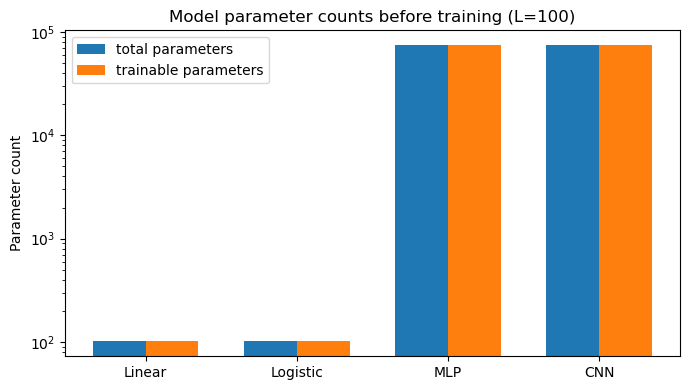

n_train=     2 | Linear(val)=1.370820 | Logistic(val)=1.154958 | MLP(val)=0.950511 | CNN(val)=0.334215
n_train=     5 | Linear(val)=0.337930 | Logistic(val)=0.425349 | MLP(val)=0.897520 | CNN(val)=0.325002
n_train=    10 | Linear(val)=0.320670 | Logistic(val)=0.361387 | MLP(val)=0.809333 | CNN(val)=0.319788
n_train=    20 | Linear(val)=0.311139 | Logistic(val)=0.316449 | MLP(val)=0.765026 | CNN(val)=0.324125
n_train=    40 | Linear(val)=0.307478 | Logistic(val)=0.306223 | MLP(val)=0.721928 | CNN(val)=0.319224
n_train=    80 | Linear(val)=0.302631 | Logistic(val)=0.293241 | MLP(val)=0.707307 | CNN(val)=0.316956


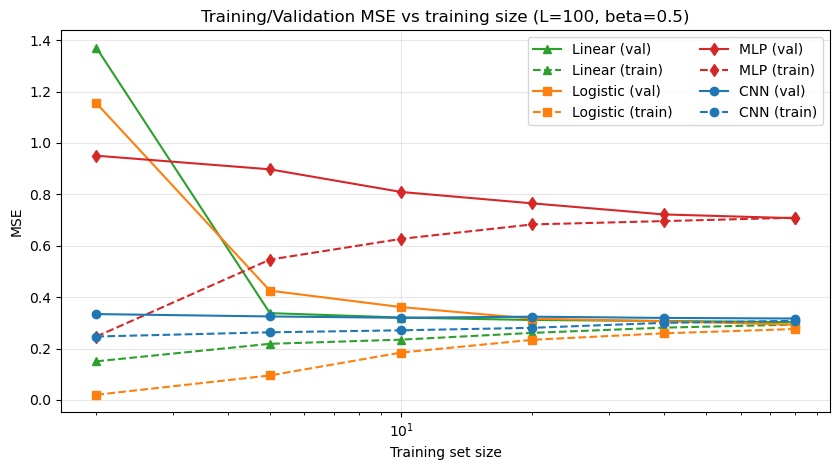

In [23]:
import matplotlib.pyplot as plt
# 4-model comparison using wrapper classes:
# 1) myLinearRegressionModel 2) myLogisticRegressionModel 3) MLPModel 4) dilatedCNNModel
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_sizes = [2, 5, 10, 20, 40, 80]
train_sizes = [n for n in train_sizes if n <= n_train_pool]
use_pbc_shared_baselines = True  # shared shift-equivariant linear/logistic model: ~L+1 params
if len(train_sizes) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
# -------- parameter count setup (before training curves) --------
def _mlp_params_for_two_hidden(L, h):
    # L->h->h->L with bias in all Linear layers
    return int(L * h + h + h * h + h + h * L + L)
def _choose_mlp_hidden_dim(L, target_params, h_min=8, h_max=4096):
    hs = np.arange(h_min, h_max + 1)
    counts = hs * hs + 2 * L * hs + 2 * hs + L
    best = int(np.argmin(np.abs(counts - target_params)))
    return int(hs[best]), int(counts[best])
# Probe CNN params via wrapper (epochs=0: build model, no training steps)
cnn_probe = dilatedCNNModel(
    hidden_channels=64,
    kernel_size=3,
    dilation_base=2,
    batch_size=64,
    epochs=0,
    augment_z2=True,
    seed=seed_curve,
    verbose=0,
)
cnn_probe.fit(X_np[:2], Y_np[:2], val_split=0.0)
cnn_counts = cnn_probe.parameter_counts()
# Choose MLP width so parameter count is comparable to CNN
mlp_h, mlp_est = _choose_mlp_hidden_dim(L_data, cnn_counts["total"])
mlp_hidden_dims = (mlp_h, mlp_h)
mlp_probe = MLPModel(
    hidden_dims=mlp_hidden_dims,
    lr=1e-3,
    batch_size=64,
    epochs=0,
    augment_z2=True,
    seed=seed_curve,
    verbose=0,
)
mlp_probe.fit(X_np[:2], Y_np[:2], val_split=0.0)
mlp_counts = mlp_probe.parameter_counts()
if use_pbc_shared_baselines:
    linlog_params = int(L_data + 1)
else:
    linlog_params = int(L_data * (L_data + 1))
model_names = ["Linear", "Logistic", "MLP", "CNN"]
total_params = [linlog_params, linlog_params, mlp_counts["total"], cnn_counts["total"]]
trainable_params = [linlog_params, linlog_params, mlp_counts["trainable"], cnn_counts["trainable"]]
print(f"Selected MLP hidden_dims={mlp_hidden_dims}, params={mlp_counts['total']:,}; CNN params={cnn_counts['total']:,}")
x = np.arange(len(model_names))
width = 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, total_params, width=width, label="total parameters")
plt.bar(x + width / 2, trainable_params, width=width, label="trainable parameters")
plt.xticks(x, model_names)
plt.ylabel("Parameter count")
plt.title(f"Model parameter counts before training (L={L_data})")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
# -------- training/validation MSE curves vs training size --------
metrics_train = {name: [] for name in model_names}
metrics_val = {name: [] for name in model_names}
for n_train in train_sizes:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    models = {
        "Linear": myLinearRegressionModel(
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "Logistic": myLogisticRegressionModel(
            solver="lbfgs",
            C=1.0,
            max_iter=400,
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "MLP": MLPModel(
            hidden_dims=mlp_hidden_dims,
            dropout=0.0,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "CNN": dilatedCNNModel(
            hidden_channels=64,
            kernel_size=3,
            dilation_base=2,
            num_blocks=None,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
    }
    for name in model_names:
        mdl = models[name]
        mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
        metrics_train[name].append(mdl.score(X_train, Y_train, metric="mse"))
        metrics_val[name].append(mdl.score(X_val, Y_val, metric="mse"))
    print(
        f"n_train={n_train:6d} | "
        f"Linear(val)={metrics_val['Linear'][-1]:.6f} | "
        f"Logistic(val)={metrics_val['Logistic'][-1]:.6f} | "
        f"MLP(val)={metrics_val['MLP'][-1]:.6f} | "
        f"CNN(val)={metrics_val['CNN'][-1]:.6f}"
    )
colors = {
    "Linear": "tab:green",
    "Logistic": "tab:orange",
    "MLP": "tab:red",
    "CNN": "tab:blue",
}
markers = {
    "Linear": "^",
    "Logistic": "s",
    "MLP": "d",
    "CNN": "o",
}
plt.figure(figsize=(8.5, 4.8))
for name in model_names:
    plt.plot(
        train_sizes,
        metrics_val[name],
        linestyle="-",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (val)",
    )
    plt.plot(
        train_sizes,
        metrics_train[name],
        linestyle="--",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (train)",
    )
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title(f"Training/Validation MSE vs training size (L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Trainable parameters:
  Linear: 101
  Logistic: 101
  CNN: 74,433
n_train=     2 | Linear(train/val)=0.151163/0.448279 | Logistic(train/val)=0.020214/1.154958 | CNN(train/val)=0.246926/0.334215
n_train=     5 | Linear(train/val)=0.222227/0.340311 | Logistic(train/val)=0.095265/0.425349 | CNN(train/val)=0.263255/0.325002
n_train=    10 | Linear(train/val)=0.236956/0.321946 | Logistic(train/val)=0.184461/0.361387 | CNN(train/val)=0.271041/0.319788
n_train=    20 | Linear(train/val)=0.262006/0.311246 | Logistic(train/val)=0.234234/0.316449 | CNN(train/val)=0.280808/0.324125
n_train=    40 | Linear(train/val)=0.281534/0.307522 | Logistic(train/val)=0.259348/0.306223 | CNN(train/val)=0.300047/0.319224
n_train=    80 | Linear(train/val)=0.293335/0.302632 | Logistic(train/val)=0.276048/0.293241 | CNN(train/val)=0.308124/0.316956
n_train=   160 | Linear(train/val)=0.292761/0.300964 | Logistic(train/val)=0.275411/0.290167 | CNN(train/val)=0.302754/0.312379
n_train=   320 | Linear(train/val)=0.2

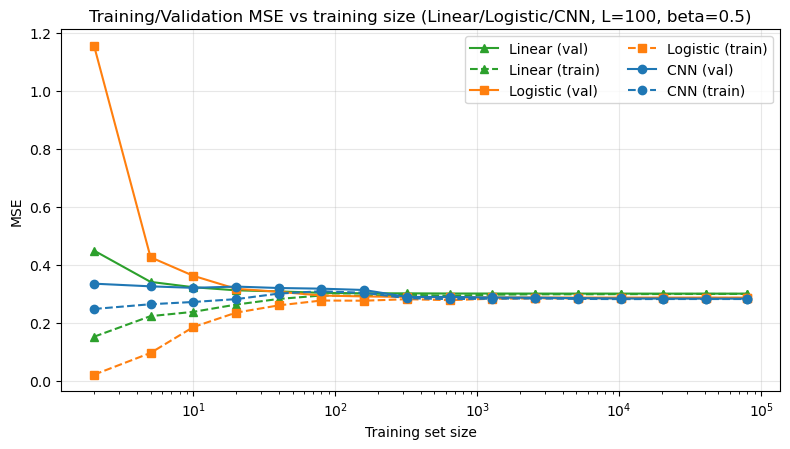

In [34]:
import matplotlib.pyplot as plt
# Compare Linear / Logistic / CNN (train + validation MSE)
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_sizes = [2, 5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000]
train_sizes = [n for n in train_sizes if n <= n_train_pool]
if len(train_sizes) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
use_pbc_shared_baselines = True
model_names = ["Linear", "Logistic", "CNN"]
metrics_train = {name: [] for name in model_names}
metrics_val = {name: [] for name in model_names}
trainable_params = None
for n_train in train_sizes:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    models = {
        "Linear": myLinearRegressionModel(
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "Logistic": myLogisticRegressionModel(
            solver="lbfgs",
            C=1.0,
            max_iter=400,
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "CNN": dilatedCNNModel(
            hidden_channels=64,
            kernel_size=3,
            dilation_base=2,
            num_blocks=None,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
    }
    for name in model_names:
        mdl = models[name]
        mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
        metrics_train[name].append(mdl.score(X_train, Y_train, metric="mse"))
        metrics_val[name].append(mdl.score(X_val, Y_val, metric="mse"))
    if trainable_params is None:
        trainable_params = {name: models[name].parameter_counts()["trainable"] for name in model_names}
        print("Trainable parameters:")
        for name in model_names:
            print(f"  {name}: {trainable_params[name]:,}")
    print(
        f"n_train={n_train:6d} | "
        f"Linear(train/val)={metrics_train['Linear'][-1]:.6f}/{metrics_val['Linear'][-1]:.6f} | "
        f"Logistic(train/val)={metrics_train['Logistic'][-1]:.6f}/{metrics_val['Logistic'][-1]:.6f} | "
        f"CNN(train/val)={metrics_train['CNN'][-1]:.6f}/{metrics_val['CNN'][-1]:.6f}"
    )
colors = {
    "Linear": "tab:green",
    "Logistic": "tab:orange",
    "CNN": "tab:blue",
}
markers = {
    "Linear": "^",
    "Logistic": "s",
    "CNN": "o",
}
plt.figure(figsize=(8, 4.6))
for name in model_names:
    plt.plot(
        train_sizes,
        metrics_val[name],
        linestyle="-",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (val)",
    )
    plt.plot(
        train_sizes,
        metrics_train[name],
        linestyle="--",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (train)",
    )
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title(f"Training/Validation MSE vs training size (Linear/Logistic/CNN, L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
Zexp = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")
MSE_true = 1 - np.mean(Zexp ** 2)
MSE_true_std = np.std(1 - Zexp ** 2) / np.sqrt(Zexp.shape[0])
print(f"True MSE (using Zexp): {MSE_true:.6f} ± {MSE_true_std:.6f}")

True MSE (using Zexp): 0.280994 ± 0.003387


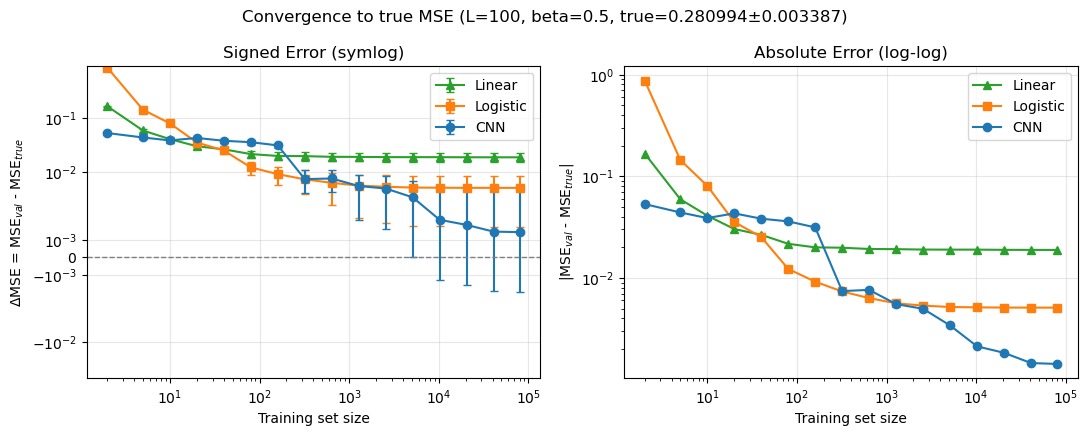

In [49]:
import numpy as np
import matplotlib.pyplot as plt
# Plot convergence to true MSE.
# Left: signed error (symlog) with error bars.
# Right: absolute error (log-log) without error bars.
train_sizes_arr = np.asarray(train_sizes, dtype=np.float64)
true_mu = float(MSE_true)
true_se = float(MSE_true_std)
eps = 1e-12
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax_signed, ax_abs = axes
for name in model_names:
    y = np.asarray(metrics_val[name], dtype=np.float64)
    delta = y - true_mu
    # Signed error with constant uncertainty from true-value estimate.
    ax_signed.errorbar(
        train_sizes_arr,
        delta,
        yerr=np.full_like(delta, true_se),
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=name,
    )
    # Absolute error in log scale (no error bars for readability).
    abs_delta = np.abs(delta)
    ax_abs.plot(
        train_sizes_arr,
        np.maximum(abs_delta, eps),
        markers[name] + "-",
        color=colors[name],
        label=name,
    )
ax_signed.axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
ax_signed.set_xscale("log")
ax_signed.set_yscale("symlog", linthresh=max(true_se, 1e-4))
ax_signed.set_xlabel("Training set size")
ax_signed.set_ylabel(r"$\Delta$MSE = MSE$_{val}$ - MSE$_{true}$")
ax_signed.set_title("Signed Error (symlog)")
ax_signed.grid(alpha=0.3)
ax_signed.legend()
ax_abs.set_xscale("log")
ax_abs.set_yscale("log")
ax_abs.set_xlabel("Training set size")
ax_abs.set_ylabel(r"$|$MSE$_{val}$ - MSE$_{true}$$|$")
ax_abs.set_title("Absolute Error (log-log)")
ax_abs.grid(alpha=0.3)
ax_abs.legend()
fig.suptitle(f"Convergence to true MSE (L={L_data}, beta={beta}, true={true_mu:.6f}±{true_se:.6f})")
plt.tight_layout()
plt.show()


n_train=     2 | Linear val=0.448279±0.000778 | Logistic val=1.154958±0.005090 | CNN val=0.334215±0.000758
n_train=     5 | Linear val=0.340311±0.000627 | Logistic val=0.425349±0.000961 | CNN val=0.325002±0.000722
n_train=    10 | Linear val=0.321946±0.000599 | Logistic val=0.361387±0.000792 | CNN val=0.319788±0.000712
n_train=    20 | Linear val=0.311246±0.000570 | Logistic val=0.316449±0.000684 | CNN val=0.324125±0.000713
n_train=    40 | Linear val=0.307522±0.000564 | Logistic val=0.306223±0.000655 | CNN val=0.319224±0.000703
n_train=    80 | Linear val=0.302632±0.000551 | Logistic val=0.293241±0.000616 | CNN val=0.316956±0.000697
n_train=   160 | Linear val=0.300964±0.000547 | Logistic val=0.290167±0.000607 | CNN val=0.312379±0.000693
n_train=   320 | Linear val=0.300805±0.000545 | Logistic val=0.288343±0.000599 | CNN val=0.288412±0.000600
n_train=   640 | Linear val=0.300245±0.000543 | Logistic val=0.287324±0.000597 | CNN val=0.288615±0.000574
n_train=  1280 | Linear val=0.300167±

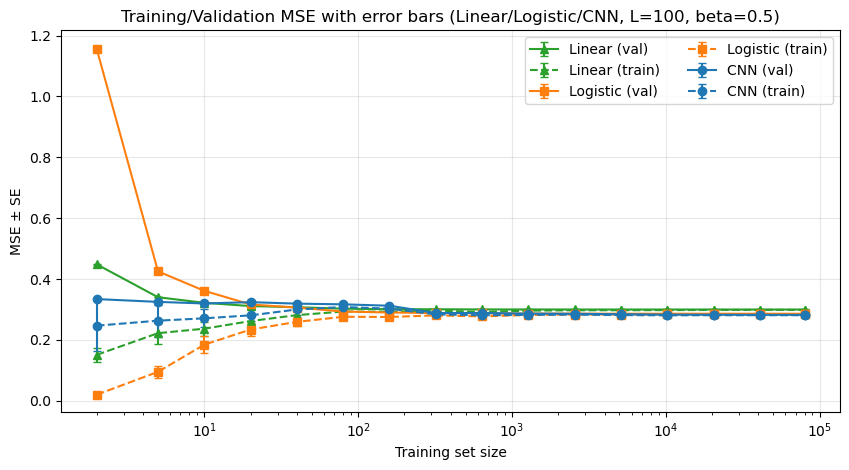

In [50]:
import numpy as np
import matplotlib.pyplot as plt
# 3-model comparison with error bars from per-snapshot MSE standard error.
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_sizes_err = [2, 5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000]
train_sizes_err = [n for n in train_sizes_err if n <= n_train_pool]
if len(train_sizes_err) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
use_pbc_shared_baselines = True
model_names = ["Linear", "Logistic", "CNN"]
colors = {"Linear": "tab:green", "Logistic": "tab:orange", "CNN": "tab:blue"}
markers = {"Linear": "^", "Logistic": "s", "CNN": "o"}
train_mean = {name: [] for name in model_names}
train_se = {name: [] for name in model_names}
val_mean = {name: [] for name in model_names}
val_se = {name: [] for name in model_names}
def mse_mean_se(y_true, y_pred):
    # Per-snapshot MSE: average over sites first, then estimate mean and SE over snapshots.
    m = np.mean((y_pred - y_true) ** 2, axis=1)
    mu = float(np.mean(m))
    se = float(np.std(m, ddof=1) / np.sqrt(m.shape[0])) if m.shape[0] > 1 else 0.0
    return mu, se
for n_train in train_sizes_err:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    models = {
        "Linear": myLinearRegressionModel(
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "Logistic": myLogisticRegressionModel(
            solver="lbfgs",
            C=1.0,
            max_iter=400,
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "CNN": dilatedCNNModel(
            hidden_channels=64,
            kernel_size=3,
            dilation_base=2,
            num_blocks=None,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
    }
    for name in model_names:
        mdl = models[name]
        mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
        y_train_pred = mdl.predict_magnetization(X_train)
        y_val_pred = mdl.predict_magnetization(X_val)
        mu_tr, se_tr = mse_mean_se(Y_train, y_train_pred)
        mu_va, se_va = mse_mean_se(Y_val, y_val_pred)
        train_mean[name].append(mu_tr)
        train_se[name].append(se_tr)
        val_mean[name].append(mu_va)
        val_se[name].append(se_va)
    print(
        f"n_train={n_train:6d} | "
        f"Linear val={val_mean['Linear'][-1]:.6f}±{val_se['Linear'][-1]:.6f} | "
        f"Logistic val={val_mean['Logistic'][-1]:.6f}±{val_se['Logistic'][-1]:.6f} | "
        f"CNN val={val_mean['CNN'][-1]:.6f}±{val_se['CNN'][-1]:.6f}"
    )
plt.figure(figsize=(8.6, 4.8))
for name in model_names:
    plt.errorbar(
        train_sizes_err,
        val_mean[name],
        yerr=val_se[name],
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=f"{name} (val)",
    )
    plt.errorbar(
        train_sizes_err,
        train_mean[name],
        yerr=train_se[name],
        fmt=markers[name] + "--",
        color=colors[name],
        capsize=3,
        label=f"{name} (train)",
    )
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE ± SE")
plt.title(f"Training/Validation MSE with error bars (Linear/Logistic/CNN, L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


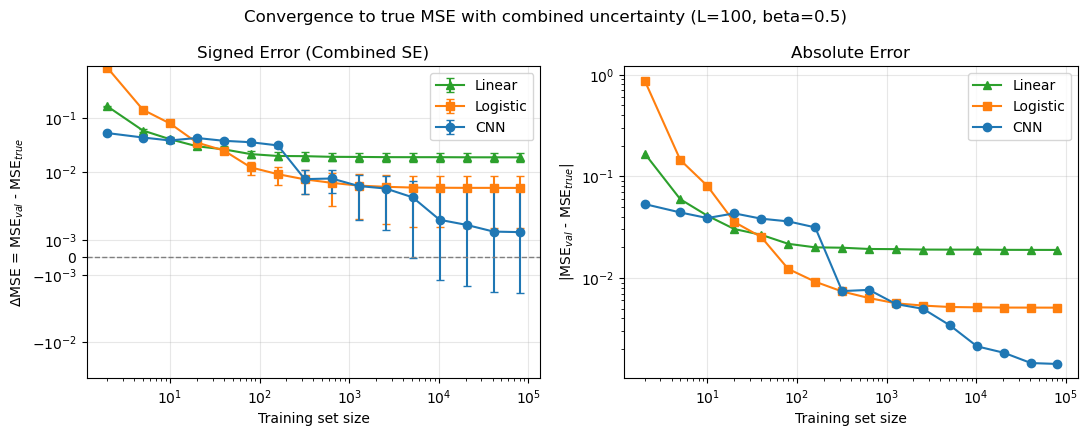

In [53]:
import numpy as np
import matplotlib.pyplot as plt
# Signed/absolute error with combined uncertainty:
# SE_combined = sqrt(SE_model^2 + SE_true^2)
true_mu = float(MSE_true)
true_se = float(MSE_true_std)
train_sizes_arr = np.asarray(train_sizes_err, dtype=np.float64)
eps = 1e-12
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax_signed, ax_abs = axes
for name in model_names:
    y = np.asarray(val_mean[name], dtype=np.float64)
    se_model = np.asarray(val_se[name], dtype=np.float64)
    delta = y - true_mu
    se_comb = np.sqrt(se_model**2 + true_se**2)
    # Signed error (can be negative)
    ax_signed.errorbar(
        train_sizes_arr,
        delta,
        yerr=se_comb,
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=name,
    )
    # Absolute error (no error bars for readability)
    abs_delta = np.abs(delta)
    ax_abs.plot(
        train_sizes_arr,
        np.maximum(abs_delta, eps),
        markers[name] + "-",
        color=colors[name],
        label=name,
    )
ax_signed.axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
ax_signed.set_xscale("log")
ax_signed.set_yscale("symlog", linthresh=max(true_se, 1e-4))
ax_signed.set_xlabel("Training set size")
ax_signed.set_ylabel(r"$\Delta$MSE = MSE$_{val}$ - MSE$_{true}$")
ax_signed.set_title("Signed Error (Combined SE)")
ax_signed.grid(alpha=0.3)
ax_signed.legend()
ax_abs.set_xscale("log")
ax_abs.set_yscale("log")
ax_abs.set_xlabel("Training set size")
ax_abs.set_ylabel(r"$|$MSE$_{val}$ - MSE$_{true}$$|$")
ax_abs.set_title("Absolute Error")
ax_abs.grid(alpha=0.3)
ax_abs.legend()
fig.suptitle(f"Convergence to true MSE with combined uncertainty (L={L_data}, beta={beta})")
plt.tight_layout()
plt.show()


## Plots for different system size and measurement strength

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt

def Plot_Convergence_Curves_PBC(L, beta, save_fig=False):
    pass
    try:
        X = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
        Y = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
        N = X.shape[0] # number of snapshots
        Zexp = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")
        MSE_true = 1 - np.mean(Zexp ** 2)
        MSE_true_std = np.std(1 - Zexp ** 2) / np.sqrt(Zexp.shape[0])
        print(f"True MSE (using Zexp): {MSE_true:.6f} ± {MSE_true_std:.6f}")
    except Exception as e:
        print(f"Error loading data: {e}")
        raise

    # 3-model comparison with error bars from per-snapshot MSE standard error.
    seed_curve = 0
    rng = np.random.default_rng(seed_curve)
    X_np = np.asarray(X, dtype=np.float32)
    Y_np = np.asarray(Y, dtype=np.float32)
    if X_np.shape != Y_np.shape:
        raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
    if X_np.ndim != 2:
        raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
    N_samples, L_data = X_np.shape
    perm = rng.permutation(N_samples)
    n_val = max(1, int(0.2 * N_samples))
    val_idx = perm[:n_val]
    train_pool_idx = perm[n_val:]
    n_train_pool = train_pool_idx.shape[0]
    X_val = X_np[val_idx]
    Y_val = Y_np[val_idx]
    train_sizes_err = [2, 5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000] # 2, 5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000
    train_sizes_err = [n for n in train_sizes_err if n <= n_train_pool]
    if len(train_sizes_err) == 0:
        raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
    use_pbc_shared_baselines = True
    model_names = ["Linear", "Logistic", "CNN"]
    colors = {"Linear": "tab:green", "Logistic": "tab:orange", "CNN": "tab:blue"}
    markers = {"Linear": "^", "Logistic": "s", "CNN": "o"}
    train_mean = {name: [] for name in model_names}
    train_se = {name: [] for name in model_names}
    val_mean = {name: [] for name in model_names}
    val_se = {name: [] for name in model_names}
    def mse_mean_se(y_true, y_pred):
        # Per-snapshot MSE: average over sites first, then estimate mean and SE over snapshots.
        m = np.mean((y_pred - y_true) ** 2, axis=1)
        mu = float(np.mean(m))
        se = float(np.std(m, ddof=1) / np.sqrt(m.shape[0])) if m.shape[0] > 1 else 0.0
        return mu, se
    for n_train in train_sizes_err:
        sub_idx = train_pool_idx[:n_train]
        X_train = X_np[sub_idx]
        Y_train = Y_np[sub_idx]
        models = {
            "Linear": myLinearRegressionModel(
                fit_intercept=True,
                pbc_augment=False,
                pbc_shared=use_pbc_shared_baselines,
                augment_z2=True,
                seed=seed_curve,
                verbose=0,
            ),
            "Logistic": myLogisticRegressionModel(
                solver="lbfgs",
                C=1.0,
                max_iter=400,
                fit_intercept=True,
                pbc_augment=False,
                pbc_shared=use_pbc_shared_baselines,
                augment_z2=True,
                seed=seed_curve,
                verbose=0,
            ),
            "CNN": dilatedCNNModel(
                hidden_channels=64,
                kernel_size=3,
                dilation_base=2,
                num_blocks=None,
                lr=1e-3,
                batch_size=256,
                epochs=20,
                augment_z2=True,
                seed=seed_curve,
                verbose=0,
            ),
        }
        for name in model_names:
            mdl = models[name]
            mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
            y_train_pred = mdl.predict_magnetization(X_train)
            y_val_pred = mdl.predict_magnetization(X_val)
            mu_tr, se_tr = mse_mean_se(Y_train, y_train_pred)
            mu_va, se_va = mse_mean_se(Y_val, y_val_pred)
            train_mean[name].append(mu_tr)
            train_se[name].append(se_tr)
            val_mean[name].append(mu_va)
            val_se[name].append(se_va)
        print(
            f"n_train={n_train:6d} | "
            f"Linear val={val_mean['Linear'][-1]:.6f}±{val_se['Linear'][-1]:.6f} | "
            f"Logistic val={val_mean['Logistic'][-1]:.6f}±{val_se['Logistic'][-1]:.6f} | "
            f"CNN val={val_mean['CNN'][-1]:.6f}±{val_se['CNN'][-1]:.6f}"
        )
    plt.figure(figsize=(8.6, 4.8))
    for name in model_names:
        plt.errorbar(
            train_sizes_err,
            val_mean[name],
            yerr=val_se[name],
            fmt=markers[name] + "-",
            color=colors[name],
            capsize=3,
            label=f"{name} (val)",
        )
        plt.errorbar(
            train_sizes_err,
            train_mean[name],
            yerr=train_se[name],
            fmt=markers[name] + "--",
            color=colors[name],
            capsize=3,
            label=f"{name} (train)",
        )
    plt.xscale("log")
    plt.xlabel("Training set size")
    plt.ylabel("MSE ± SE")
    plt.title(f"Training/Validation MSE with error bars (Linear/Logistic/CNN, L={L_data}, beta={beta})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # Signed/absolute error with combined uncertainty:
    # SE_combined = sqrt(SE_model^2 + SE_true^2)
    true_mu = float(MSE_true)
    true_se = float(MSE_true_std)
    train_sizes_arr = np.asarray(train_sizes_err, dtype=np.float64)
    eps = 1e-12
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    ax_signed, ax_abs = axes
    for name in model_names:
        y = np.asarray(val_mean[name], dtype=np.float64)
        se_model = np.asarray(val_se[name], dtype=np.float64)
        delta = (y - true_mu) / (1 - true_mu) # relative error to irreducible error
        se_comb = np.sqrt(se_model**2 + true_se**2 + true_se**2) / (1 - true_mu) # combined SE (model + true) relative to irreducible error
        # Signed error (can be negative)
        ax_signed.errorbar(
            train_sizes_arr,
            delta,
            yerr=se_comb,
            fmt=markers[name] + "-",
            color=colors[name],
            capsize=3,
            label=name,
        )
        # Absolute error (no error bars for readability)
        abs_delta = np.abs(delta)
        ax_abs.plot(
            train_sizes_arr,
            np.maximum(abs_delta, eps),
            markers[name] + "-",
            color=colors[name],
            label=name,
        )
    ax_signed.axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
    ax_signed.set_xscale("log")
    ax_signed.set_yscale("symlog", linthresh=max(true_se, 1e-4))
    ax_signed.set_xlabel("Training set size")
    ax_signed.set_ylabel(r"Relative signed error $\frac{\Delta A}{1 - A_{true}}$")
    ax_signed.set_title("Relative Signed Error (Combined SE)")
    ax_signed.grid(alpha=0.3)
    ax_signed.legend()
    ax_abs.set_xscale("log")
    ax_abs.set_yscale("log")
    ax_abs.set_xlabel("Training set size")
    ax_abs.set_ylabel(r"Relative absolute error $\frac{|\Delta A|}{1 - A_{true}}$")
    ax_abs.set_title("Relative Absolute Error")
    ax_abs.grid(alpha=0.3)
    ax_abs.legend()
    fig.suptitle(rf"Convergence to true $A \equiv \overline{{\langle Z \rangle^2}}$ with combined uncertainty (L={L_data}, beta={beta})")
    plt.tight_layout()
    plt.show()
    if save_fig:
        fig.savefig(f"Convergence_Curves_PBC_L{L}_beta{beta}.png", dpi=300)


True MSE (using Zexp): 0.803929 ± 0.001794
n_train=     2 | Linear val=1.143537±0.003336 | Logistic val=1.447340±0.003934 | CNN val=1.156357±0.003933
n_train=     5 | Linear val=1.020352±0.001910 | Logistic val=1.168323±0.002593 | CNN val=1.024353±0.001974
n_train=    10 | Linear val=0.915454±0.001795 | Logistic val=0.955833±0.002096 | CNN val=0.908366±0.001779
n_train=    20 | Linear val=0.857739±0.002002 | Logistic val=0.862658±0.002242 | CNN val=0.856527±0.002004
n_train=    40 | Linear val=0.833357±0.001998 | Logistic val=0.838847±0.002136 | CNN val=0.840747±0.002020
n_train=    80 | Linear val=0.817566±0.002141 | Logistic val=0.817007±0.002320 | CNN val=0.824154±0.002228
n_train=   160 | Linear val=0.816058±0.002192 | Logistic val=0.817591±0.002402 | CNN val=0.822061±0.002318
n_train=   320 | Linear val=0.813024±0.002199 | Logistic val=0.812499±0.002365 | CNN val=0.810920±0.002355
n_train=   640 | Linear val=0.812130±0.002235 | Logistic val=0.808981±0.002376 | CNN val=0.808088±0.0

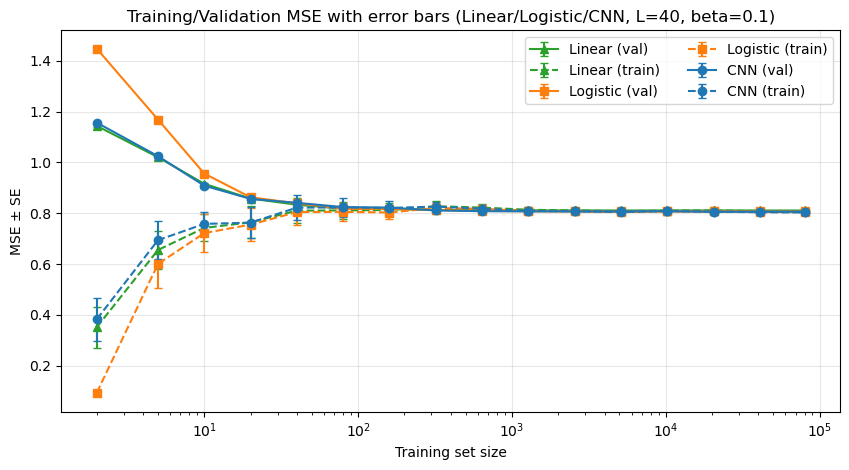

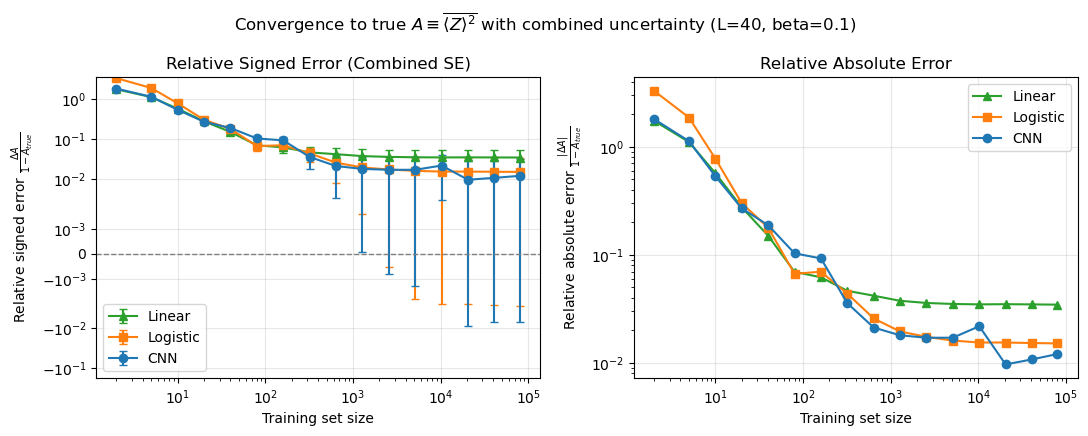

In [30]:
Plot_Convergence_Curves_PBC(L=40, beta=0.1, save_fig=True)

True MSE (using Zexp): 0.282687 ± 0.003388
n_train=     2 | Linear val=0.539598±0.001561 | Logistic val=0.427609±0.001476 | CNN val=0.423319±0.001433
n_train=     5 | Linear val=0.348231±0.000978 | Logistic val=0.381724±0.001286 | CNN val=0.353052±0.001185
n_train=    10 | Linear val=0.334184±0.000948 | Logistic val=0.371747±0.001237 | CNN val=0.333045±0.001116
n_train=    20 | Linear val=0.320697±0.000919 | Logistic val=0.326280±0.001083 | CNN val=0.333221±0.001109
n_train=    40 | Linear val=0.312212±0.000898 | Logistic val=0.302203±0.000991 | CNN val=0.316435±0.001072
n_train=    80 | Linear val=0.306182±0.000881 | Logistic val=0.294976±0.000973 | CNN val=0.309888±0.001067
n_train=   160 | Linear val=0.303194±0.000871 | Logistic val=0.290410±0.000961 | CNN val=0.304503±0.001064
n_train=   320 | Linear val=0.302320±0.000865 | Logistic val=0.288958±0.000949 | CNN val=0.289005±0.000919
n_train=   640 | Linear val=0.301577±0.000861 | Logistic val=0.287694±0.000945 | CNN val=0.287945±0.0

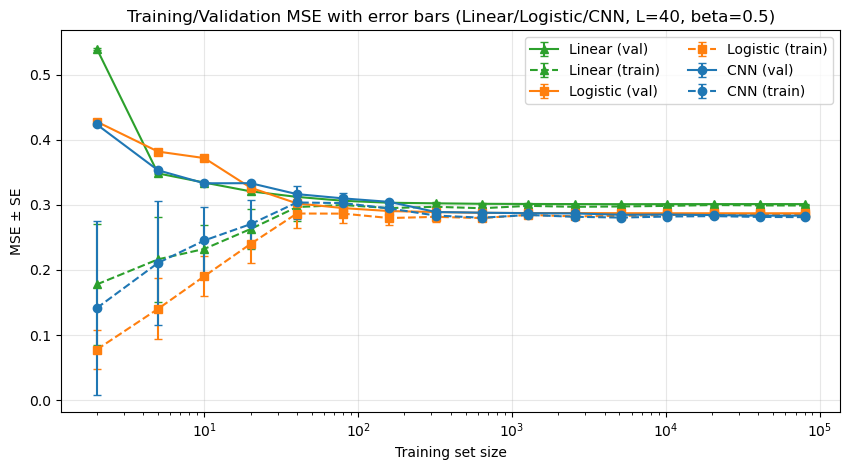

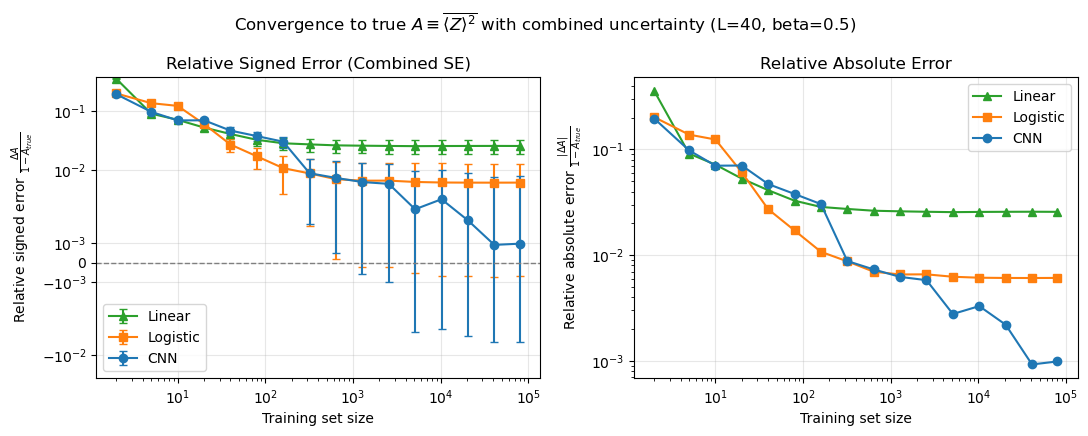

In [31]:
Plot_Convergence_Curves_PBC(L=40, beta=0.5, save_fig=True)

True MSE (using Zexp): 0.063148 ± 0.001456
n_train=     2 | Linear val=0.118049±0.000533 | Logistic val=0.487289±0.002692 | CNN val=0.083742±0.000577
n_train=     5 | Linear val=0.084243±0.000463 | Logistic val=0.108792±0.000571 | CNN val=0.080303±0.000544
n_train=    10 | Linear val=0.071437±0.000472 | Logistic val=0.102808±0.000578 | CNN val=0.077292±0.000535
n_train=    20 | Linear val=0.067424±0.000501 | Logistic val=0.080577±0.000530 | CNN val=0.076628±0.000550
n_train=    40 | Linear val=0.066936±0.000492 | Logistic val=0.075181±0.000513 | CNN val=0.072898±0.000540
n_train=    80 | Linear val=0.066137±0.000494 | Logistic val=0.068558±0.000486 | CNN val=0.070803±0.000542
n_train=   160 | Linear val=0.065871±0.000494 | Logistic val=0.065974±0.000482 | CNN val=0.070000±0.000543
n_train=   320 | Linear val=0.065654±0.000491 | Logistic val=0.064711±0.000474 | CNN val=0.064503±0.000496
n_train=   640 | Linear val=0.065542±0.000492 | Logistic val=0.064085±0.000471 | CNN val=0.064119±0.0

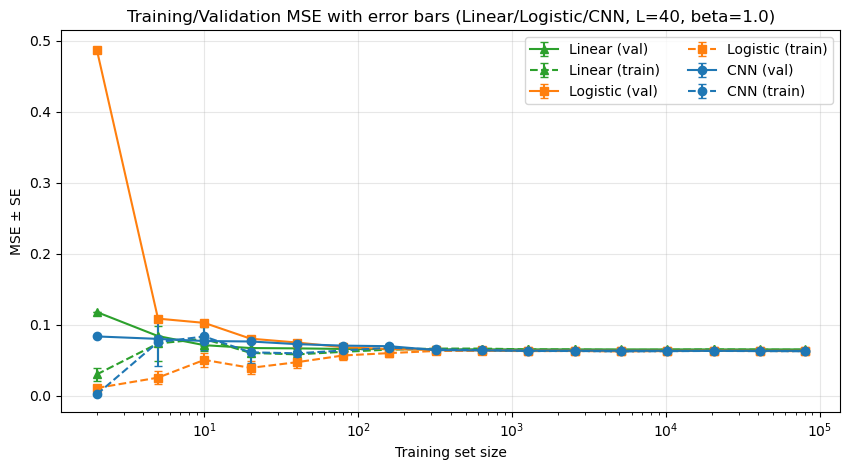

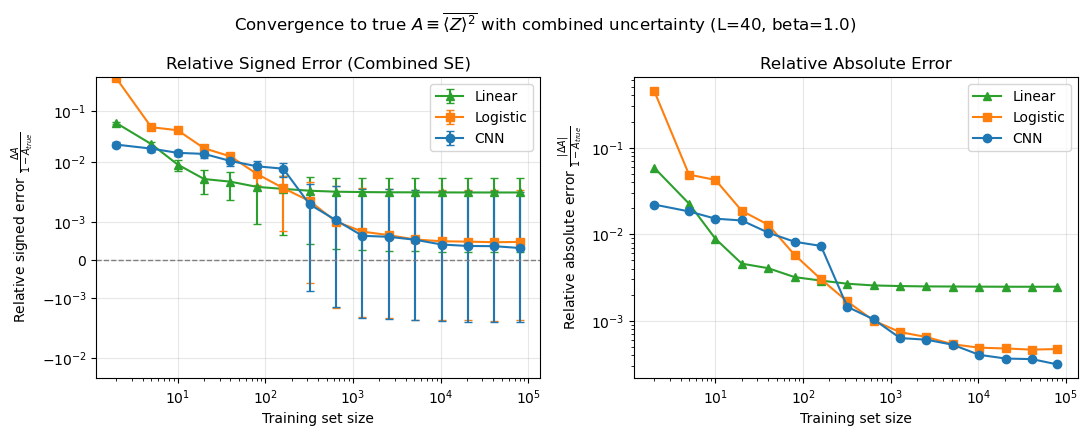

In [29]:
Plot_Convergence_Curves_PBC(L=40, beta=1.0, save_fig=True)

True MSE (using Zexp): 0.758946 ± 0.001957
n_train=     2 | Linear val=1.198545±0.001920 | Logistic val=1.403340±0.001896 | CNN val=1.053195±0.001984
n_train=     5 | Linear val=0.886799±0.001807 | Logistic val=0.919925±0.001918 | CNN val=0.858541±0.001879
n_train=    10 | Linear val=0.832787±0.001741 | Logistic val=0.842316±0.001906 | CNN val=0.818685±0.001852
n_train=    20 | Linear val=0.809519±0.001630 | Logistic val=0.810455±0.001798 | CNN val=0.804574±0.001713
n_train=    40 | Linear val=0.794400±0.001676 | Logistic val=0.792002±0.001782 | CNN val=0.793509±0.001767
n_train=    80 | Linear val=0.781229±0.001715 | Logistic val=0.778025±0.001851 | CNN val=0.777422±0.001814
n_train=   160 | Linear val=0.776076±0.001701 | Logistic val=0.771994±0.001842 | CNN val=0.773684±0.001785
n_train=   320 | Linear val=0.774460±0.001729 | Logistic val=0.770878±0.001882 | CNN val=0.768871±0.001883
n_train=   640 | Linear val=0.772462±0.001731 | Logistic val=0.767109±0.001854 | CNN val=0.766596±0.0

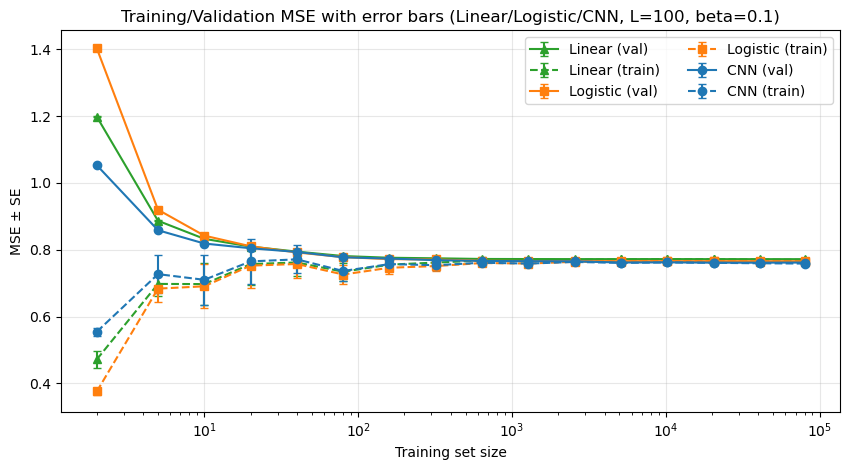

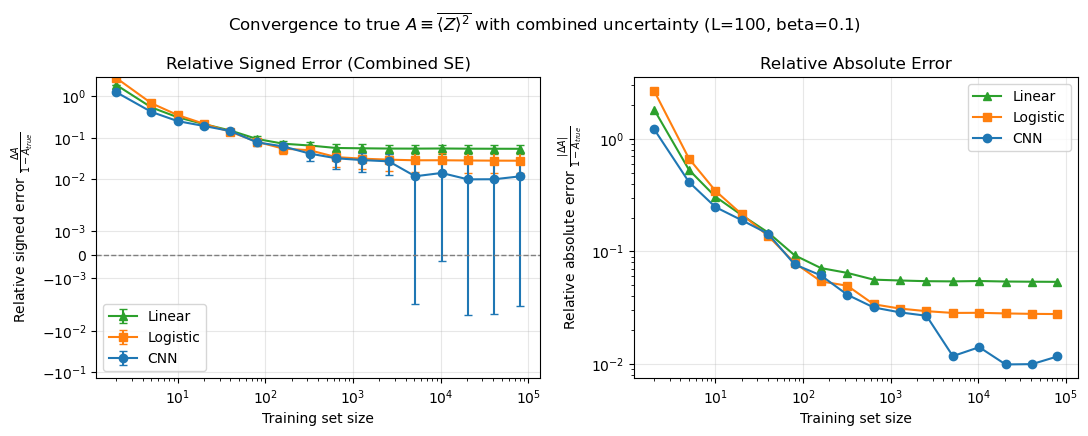

In [28]:
Plot_Convergence_Curves_PBC(L=100, beta=0.1, save_fig=True)

True MSE (using Zexp): 0.280994 ± 0.003387
n_train=     2 | Linear val=0.448279±0.000778 | Logistic val=1.154958±0.005090 | CNN val=0.423484±0.000952
n_train=     5 | Linear val=0.340311±0.000627 | Logistic val=0.425349±0.000961 | CNN val=0.327994±0.000723
n_train=    10 | Linear val=0.321946±0.000599 | Logistic val=0.361387±0.000792 | CNN val=0.307526±0.000672
n_train=    20 | Linear val=0.311246±0.000570 | Logistic val=0.316449±0.000684 | CNN val=0.301646±0.000655
n_train=    40 | Linear val=0.307522±0.000564 | Logistic val=0.306223±0.000655 | CNN val=0.297051±0.000632
n_train=    80 | Linear val=0.302632±0.000551 | Logistic val=0.293241±0.000616 | CNN val=0.290985±0.000611
n_train=   160 | Linear val=0.300964±0.000547 | Logistic val=0.290167±0.000607 | CNN val=0.289845±0.000608
n_train=   320 | Linear val=0.300805±0.000545 | Logistic val=0.288343±0.000599 | CNN val=0.288865±0.000609
n_train=   640 | Linear val=0.300245±0.000543 | Logistic val=0.287324±0.000597 | CNN val=0.286339±0.0

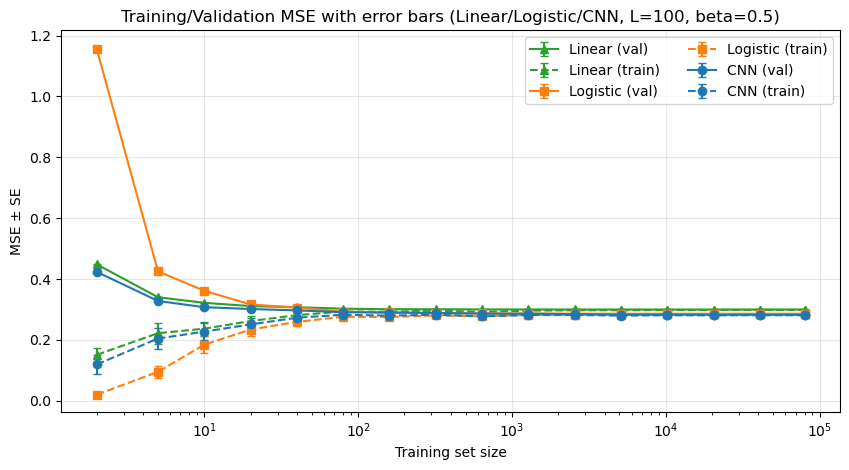

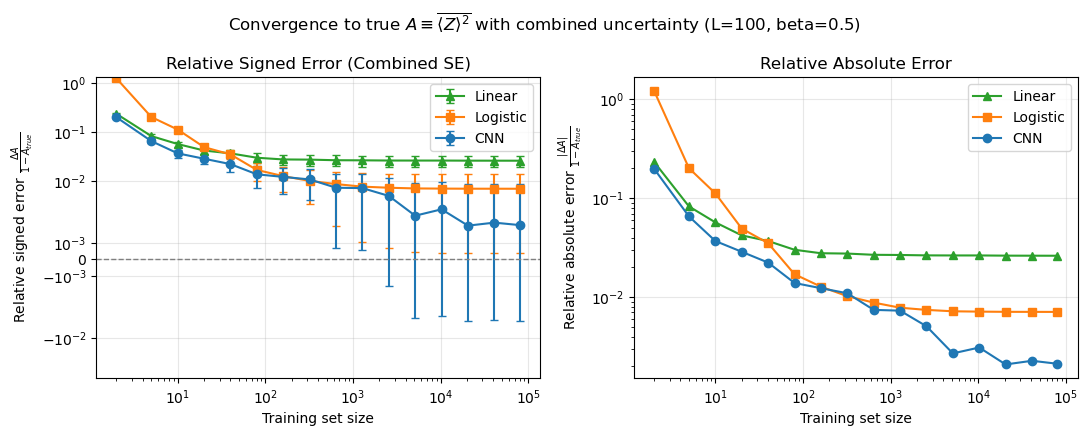

In [27]:
Plot_Convergence_Curves_PBC(L=100, beta=0.5, save_fig=True)

True MSE (using Zexp): 0.062690 ± 0.001453
n_train=     2 | Linear val=0.100682±0.000330 | Logistic val=0.115036±0.000347 | CNN val=0.102128±0.000389
n_train=     5 | Linear val=0.076492±0.000323 | Logistic val=0.093802±0.000363 | CNN val=0.073331±0.000329
n_train=    10 | Linear val=0.069903±0.000331 | Logistic val=0.082750±0.000368 | CNN val=0.067878±0.000344
n_train=    20 | Linear val=0.068170±0.000315 | Logistic val=0.082182±0.000356 | CNN val=0.067829±0.000346
n_train=    40 | Linear val=0.066468±0.000307 | Logistic val=0.076451±0.000324 | CNN val=0.066677±0.000318
n_train=    80 | Linear val=0.065782±0.000310 | Logistic val=0.067995±0.000306 | CNN val=0.066611±0.000316
n_train=   160 | Linear val=0.065650±0.000312 | Logistic val=0.066042±0.000305 | CNN val=0.066477±0.000320
n_train=   320 | Linear val=0.065509±0.000310 | Logistic val=0.064781±0.000299 | CNN val=0.064130±0.000306
n_train=   640 | Linear val=0.065435±0.000311 | Logistic val=0.064153±0.000298 | CNN val=0.063649±0.0

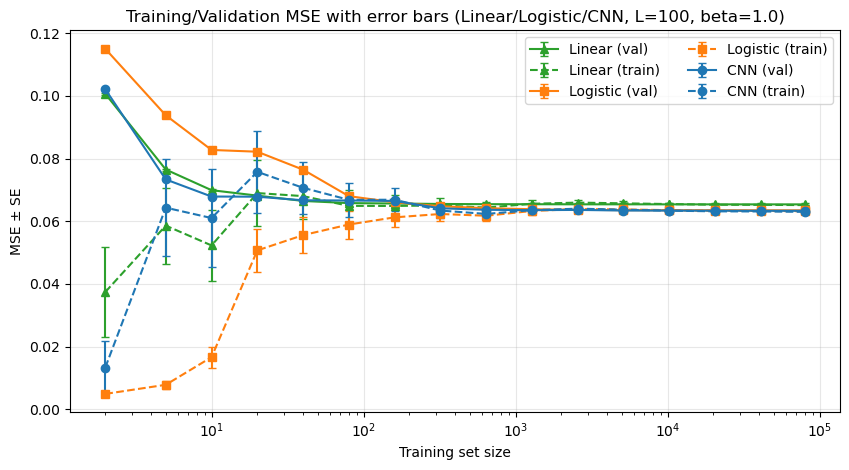

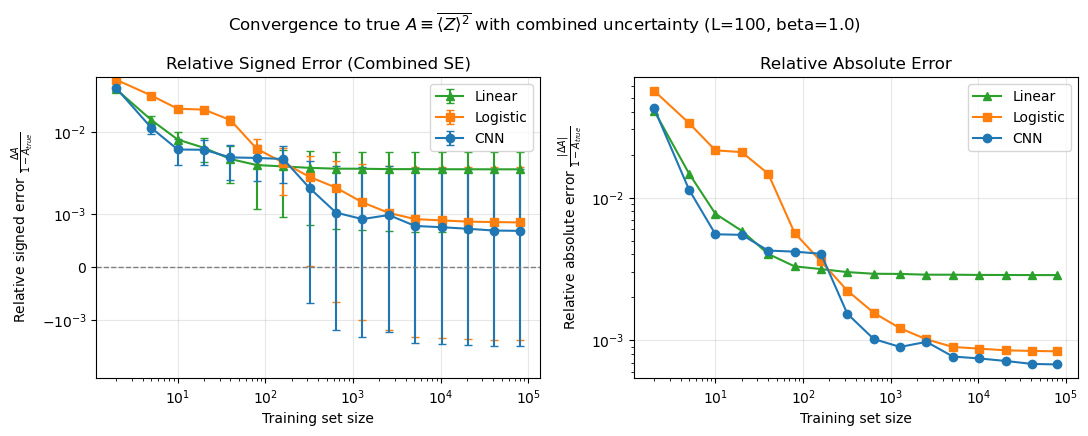

In [26]:
Plot_Convergence_Curves_PBC(L=100, beta=1.0, save_fig=True)

True MSE (using Zexp): 0.283981 ± 0.003381
n_train=     2 | Linear val=0.432740±0.001709 | Logistic val=0.369595±0.001738 | CNN val=0.440652±0.002075
n_train=     5 | Linear val=0.330520±0.001369 | Logistic val=0.332222±0.001584 | CNN val=0.366224±0.001802
n_train=    10 | Linear val=0.313595±0.001274 | Logistic val=0.326872±0.001535 | CNN val=0.321239±0.001574
n_train=    20 | Linear val=0.311469±0.001257 | Logistic val=0.311742±0.001447 | CNN val=0.313904±0.001479
n_train=    40 | Linear val=0.306878±0.001252 | Logistic val=0.303428±0.001416 | CNN val=0.309215±0.001447
n_train=    80 | Linear val=0.306376±0.001228 | Logistic val=0.292505±0.001333 | CNN val=0.292928±0.001329
n_train=   160 | Linear val=0.304008±0.001232 | Logistic val=0.290924±0.001359 | CNN val=0.291447±0.001370
n_train=   320 | Linear val=0.303549±0.001225 | Logistic val=0.289723±0.001337 | CNN val=0.290729±0.001370
n_train=   640 | Linear val=0.303335±0.001224 | Logistic val=0.288828±0.001342 | CNN val=0.288805±0.0

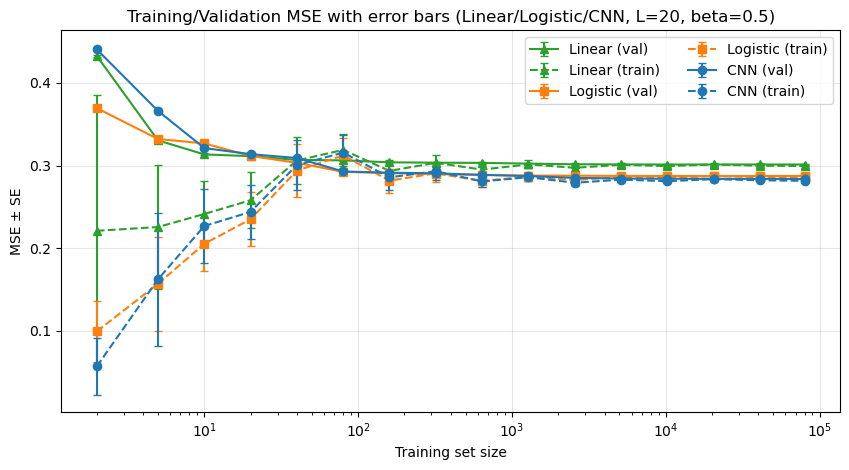

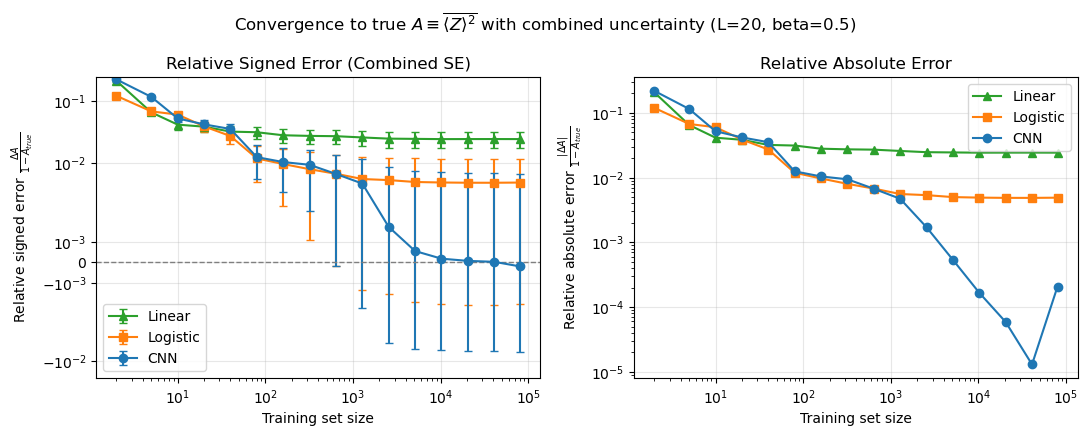

In [32]:
Plot_Convergence_Curves_PBC(L=20, beta=0.5, save_fig=True)

True MSE (using Zexp): 0.281492 ± 0.003387
n_train=     2 | Linear val=0.412018±0.001002 | Logistic val=0.673423±0.001945 | CNN val=0.345520±0.001007
n_train=     5 | Linear val=0.355554±0.000835 | Logistic val=0.405358±0.001130 | CNN val=0.354311±0.000970
n_train=    10 | Linear val=0.324253±0.000776 | Logistic val=0.356675±0.001000 | CNN val=0.325044±0.000915
n_train=    20 | Linear val=0.313178±0.000745 | Logistic val=0.317333±0.000880 | CNN val=0.327694±0.000919
n_train=    40 | Linear val=0.305296±0.000723 | Logistic val=0.299053±0.000813 | CNN val=0.309941±0.000879
n_train=    80 | Linear val=0.302920±0.000715 | Logistic val=0.293094±0.000790 | CNN val=0.306142±0.000869
n_train=   160 | Linear val=0.300619±0.000708 | Logistic val=0.289743±0.000783 | CNN val=0.302720±0.000868
n_train=   320 | Linear val=0.301003±0.000706 | Logistic val=0.288307±0.000774 | CNN val=0.287556±0.000747
n_train=   640 | Linear val=0.300562±0.000703 | Logistic val=0.287368±0.000772 | CNN val=0.287434±0.0

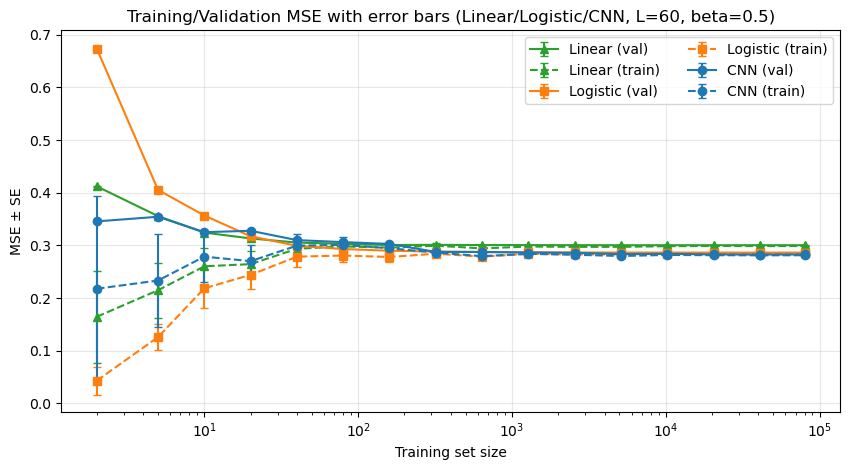

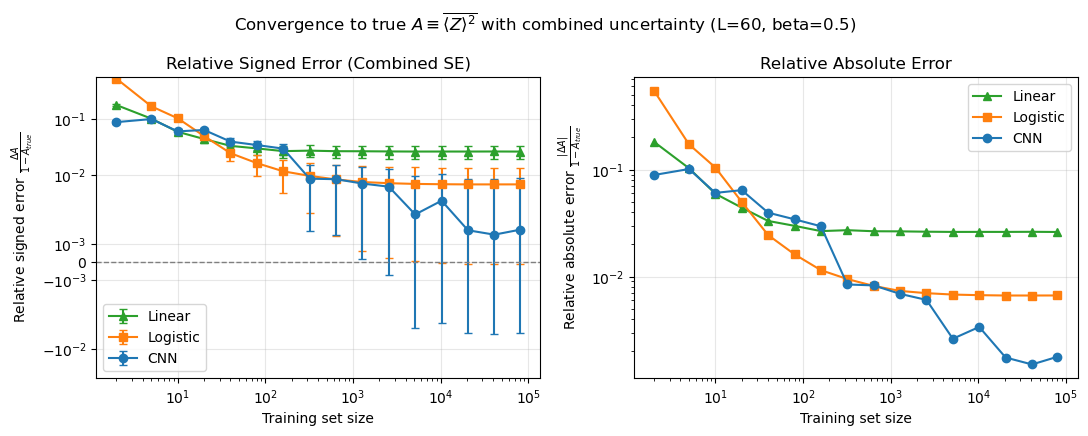

In [33]:
Plot_Convergence_Curves_PBC(L=60, beta=0.5, save_fig=True)

True MSE (using Zexp): 0.281214 ± 0.003388
n_train=     2 | Linear val=0.475516±0.000615 | Logistic val=1.106759±0.004411 | CNN val=0.345613±0.000542
n_train=     5 | Linear val=0.350813±0.000458 | Logistic val=0.475897±0.000767 | CNN val=0.305576±0.000469
n_train=    10 | Linear val=0.325693±0.000421 | Logistic val=0.378072±0.000589 | CNN val=0.298959±0.000459
n_train=    20 | Linear val=0.313877±0.000404 | Logistic val=0.324151±0.000494 | CNN val=0.295972±0.000457
n_train=    40 | Linear val=0.305629±0.000394 | Logistic val=0.303524±0.000457 | CNN val=0.295364±0.000450
n_train=    80 | Linear val=0.301932±0.000388 | Logistic val=0.292815±0.000433 | CNN val=0.294845±0.000442
n_train=   160 | Linear val=0.300511±0.000386 | Logistic val=0.289353±0.000426 | CNN val=0.295953±0.000443
n_train=   320 | Linear val=0.300087±0.000384 | Logistic val=0.287548±0.000421 | CNN val=0.286860±0.000422
n_train=   640 | Linear val=0.299693±0.000384 | Logistic val=0.286640±0.000420 | CNN val=0.286265±0.0

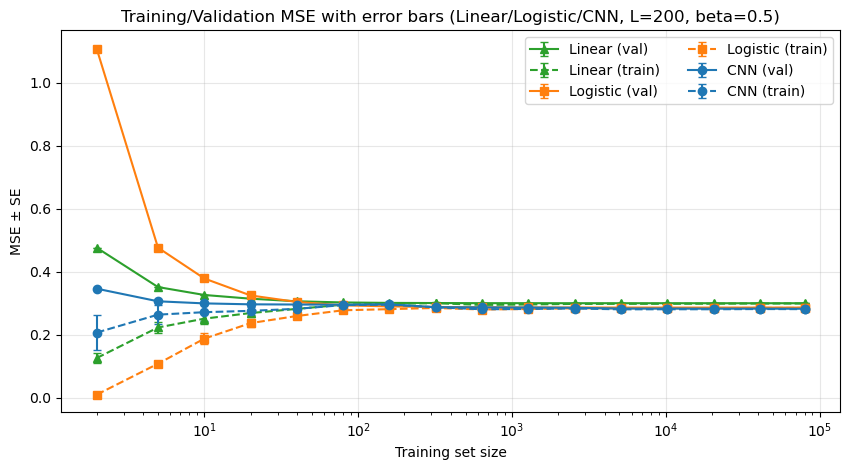

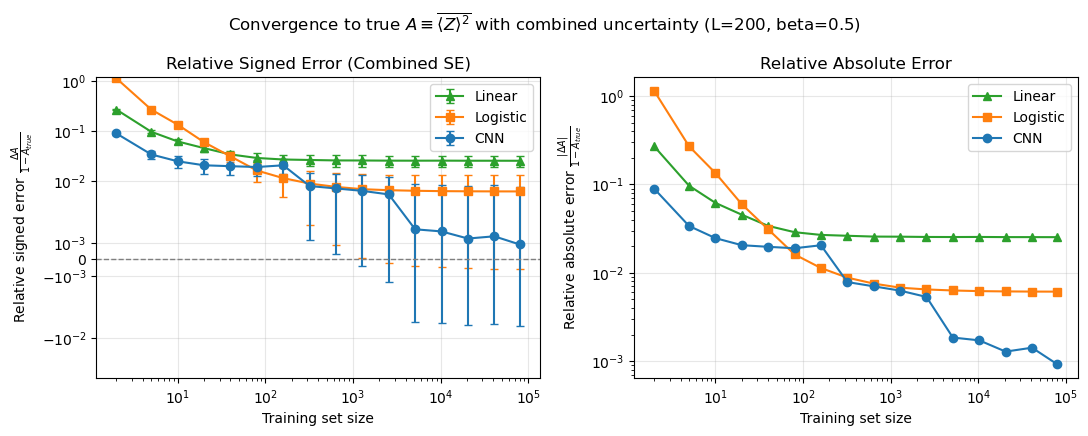

In [34]:
Plot_Convergence_Curves_PBC(L=200, beta=0.5, save_fig=True)

Text(0.5, 1.0, '$\\beta = 0.5$')

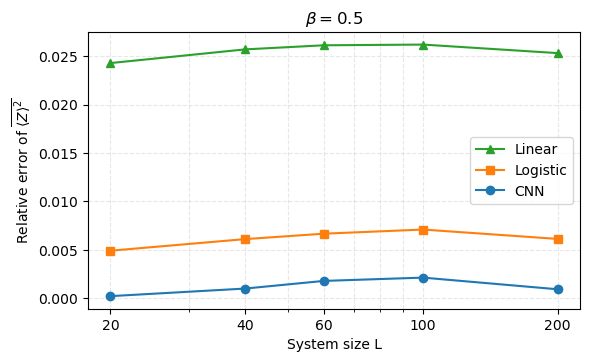

In [48]:
y_20_true = 0.283981
y_20_lin = 0.301372
y_20_log = 0.287490
y_20_cnn = 0.283833

y_40_true = 0.282687
y_40_lin = 0.301123
y_40_log = 0.287062
y_40_cnn = 0.283397

y_60_true = 0.281492
y_60_lin = 0.300263
y_60_log = 0.286277
y_60_cnn = 0.282771

y_100_true = 0.280994
y_100_lin = 0.299831
y_100_log = 0.286090
y_100_cnn = 0.282519

y_200_true = 0.281214
y_200_lin = 0.299412
y_200_log = 0.285612
y_200_cnn = 0.281873

# absolute relative error to irreducible error (1 - true value)
rel_err_lin = np.abs(np.array([y_20_lin, y_40_lin, y_60_lin, y_100_lin, y_200_lin]) - np.array([y_20_true, y_40_true, y_60_true, y_100_true, y_200_true])) / (1 - np.array([y_20_true, y_40_true, y_60_true, y_100_true, y_200_true]))
rel_err_log = np.abs(np.array([y_20_log, y_40_log, y_60_log, y_100_log, y_200_log]) - np.array([y_20_true, y_40_true, y_60_true, y_100_true, y_200_true])) / (1 - np.array([y_20_true, y_40_true, y_60_true, y_100_true, y_200_true]))
rel_err_cnn = np.abs(np.array([y_20_cnn, y_40_cnn, y_60_cnn, y_100_cnn, y_200_cnn]) - np.array([y_20_true, y_40_true, y_60_true, y_100_true, y_200_true])) / (1 - np.array([y_20_true, y_40_true, y_60_true, y_100_true, y_200_true]))
plt.figure(figsize=(6, 3.5))
L_values = np.array([20, 40, 60, 100, 200])
plt.plot(L_values, rel_err_lin, marker="^", color="tab:green", label="Linear")
plt.plot(L_values, rel_err_log, marker="s", color="tab:orange", label="Logistic")
plt.plot(L_values, rel_err_cnn, marker="o", color="tab:blue", label="CNN")
plt.xscale("log")
# plt.yscale("log")

plt.legend()
plt.xlabel("System size L")
plt.ylabel(r"Relative error of $\overline{\langle Z \rangle^2}$")
plt.xticks(L_values, [str(L) for L in L_values])
plt.tight_layout()
plt.grid(alpha=0.3, which="both", linestyle="--")
plt.title(r"$\beta = 0.5$")

## Test predictions

Snapshot 2: [-1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1 -1  1 -1 -1 -1 -1 -1  1  1  1  1  1
 -1  1  1  1  1  1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1 -1 -1 -1  1 -1 -1
 -1 -1 -1 -1  1 -1 -1 -1 -1  1  1  1 -1 -1 -1  1  1  1  1  1  1  1 -1  1
 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1  1 -1 -1 -1 -1 -1  1 -1  1
 -1 -1 -1 -1]
Zexp: [[ 0.9435207   0.23816027  0.95192689 ...  0.94255718  0.22827607
   0.94259198]
 [ 0.86351189  0.17689909  0.94534178 ...  0.17639653  0.86336984
   0.12740477]
 [-0.95371065 -0.25152933 -0.9537956  ... -0.97431797 -0.97689519
  -0.97522928]
 ...
 [ 0.97831875  0.97794625  0.97579765 ...  0.97796668  0.97832635
   0.9783881 ]
 [ 0.44235554 -0.81153378 -0.92415226 ... -0.76908507 -0.6904777
   0.47056291]
 [ 0.97673656  0.97626673  0.97332108 ...  0.97459829  0.97602781
   0.97660399]]


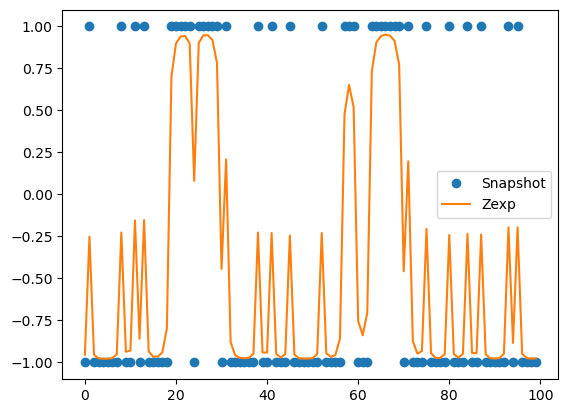

In [60]:
beta = 0.5
L = 100
X = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
i = 2
x = X[i]
print(f"Snapshot {i}: {x}")
Zexp = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")
print(f"Zexp: {Zexp}")
plt.plot(X[i], marker="o", linestyle="", label="Snapshot")
plt.plot(Zexp[i], linestyle="-", label="Zexp")
plt.legend()

In [ ]:
import MPSToolBox as my
psi_path = f"../wavefunctions/CritIsingModel_L{L}_chi300_PBC_.pkl"
psi = my.load_pkl(psi_path)
gates = [my.expm(beta * s[i] * my.sZ) for i in range(L)]
psi_measured = my.gate_onsite1(psi, gates, np.arange(L))
psi_measured.canonical_form()
psi_measured.expectation_value("Sigmaz")

Imported MPSToolBox


In [67]:
s = X[i]
print(s.tolist())

[-1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, 1, -1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, 1, -1, -1, -1, -1]


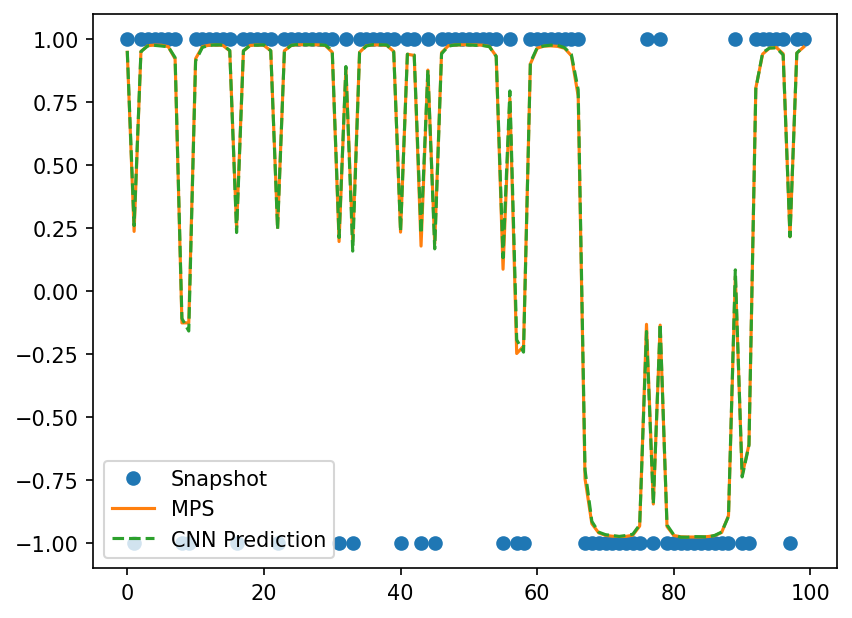

In [ ]:
from pathlib import Path
# import MPSToolBox as my

# psi_path = f"../wavefunctions/CritIsingModel_L{L}_chi300_PBC_.pkl"
# psi = my.load_pkl(psi_path)
# gates = [my.expm(beta * s[i] * my.sZ) for i in range(L)]
# psi_measured = my.gate_onsite1(psi, gates, np.arange(L))
# psi_measured.canonical_form()
# Zexp = psi_measured.expectation_value("Sigmaz") # Error due to version mismatch of Tenpy

# measurement outcome from validation set
s = [1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1, 1]

Zexp = [0.9482362036114398, 0.23726664087863517, 0.951143756044781, 0.9744796335090715, 0.9767762113870042, 0.9761391867035544, 0.970431142602581, 0.9220727064712133, -0.1257287648832543, -0.12541858211094112, 0.9225576299527822, 0.970746008454795, 0.9764438016700304, 0.9771918802575102, 0.9752855562190098, 0.953759864604575, 0.25181577412216183, 0.9538846775353867, 0.9754008089529851, 0.9772362561824438, 0.9754544508305469, 0.9541277882993091, 0.25335247377280334, 0.9542786315895514, 0.9756728473256505, 0.9778268125859532, 0.9781609739695802, 0.978105707217673, 0.9775763753908869, 0.9746607856682393, 0.9483380395909897, 0.19712765258496942, 0.88453859463925, 0.19675073135858864, 0.9481276072398767, 0.9744908914261697, 0.9773054603423872, 0.9773855426186121, 0.9750009619391645, 0.9516525902719117, 0.23445250802625794, 0.9404425080744849, 0.9355556358096131, 0.17910968377205852, 0.8776551631337357, 0.1888001814810263, 0.9468195742940898, 0.9741829990316342, 0.9772823005935731, 0.9778252085550106, 0.9778432040419444, 0.9775286790610265, 0.976392345215821, 0.9712241549988658, 0.9325307502553011, 0.0872344622195817, 0.7658717958039966, -0.24713530308096313, -0.21815734832214895, 0.9017156800182479, 0.9642340166564863, 0.9726581033482748, 0.9735924617233763, 0.9715942520220509, 0.9641418744114274, 0.9345743758569875, 0.7745524371295222, -0.7437776447588489, -0.9226493848561353, -0.9588483329410498, -0.9688228401699718, -0.9722823696502053, -0.9734634825904503, -0.9729825537829446, -0.968086687106486, -0.9318587419952717, -0.13135252995543958, -0.844446035241192, -0.13440649651053685, -0.9337352475966411, -0.9693888707555797, -0.9743633275010034, -0.9753693967200323, -0.9754006497301557, -0.9748773337670862, -0.9735256870701442, -0.9699248637506712, -0.9573600640676809, -0.8903964036372046, 0.05803075805834255, -0.729997722318278, -0.608258618645825, 0.8066167734398423, 0.9411576656263829, 0.9647662015524862, 0.9674673521098078, 0.9425299970511741, 0.2160035079710859, 0.9450939242826669, 0.9687333096402221]

model_path = f"temp/dilatedcnn_L{L}_beta{beta}.pt"
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
# CNN-only prediction
if "model" in globals() and hasattr(model, "eval"):
    with torch.no_grad():
        y_pred = model(torch.from_numpy(x_input)).cpu().numpy()[0]
else:
    ckpt_path = Path(model_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cnn_net = dialtedCNN(
        input_length=int(ckpt["L"]),
        hidden_channels=int(ckpt["hidden_channels"]),
        kernel_size=int(ckpt["kernel_size"]),
        dilation_base=int(ckpt["dilation_base"]),
        num_blocks=int(ckpt["num_blocks"]),
    )
    cnn_net.load_state_dict(ckpt["model_state_dict"])
    cnn_net.eval()
    with torch.no_grad():
        y_pred = cnn_net(torch.from_numpy(x_input)).cpu().numpy()[0]
plt.plot(s, marker="o", linestyle="", label="Snapshot")
plt.plot(Zexp, linestyle="-", label="MPS")
plt.plot(y_pred, linestyle="--", label="CNN Prediction")
plt.legend()


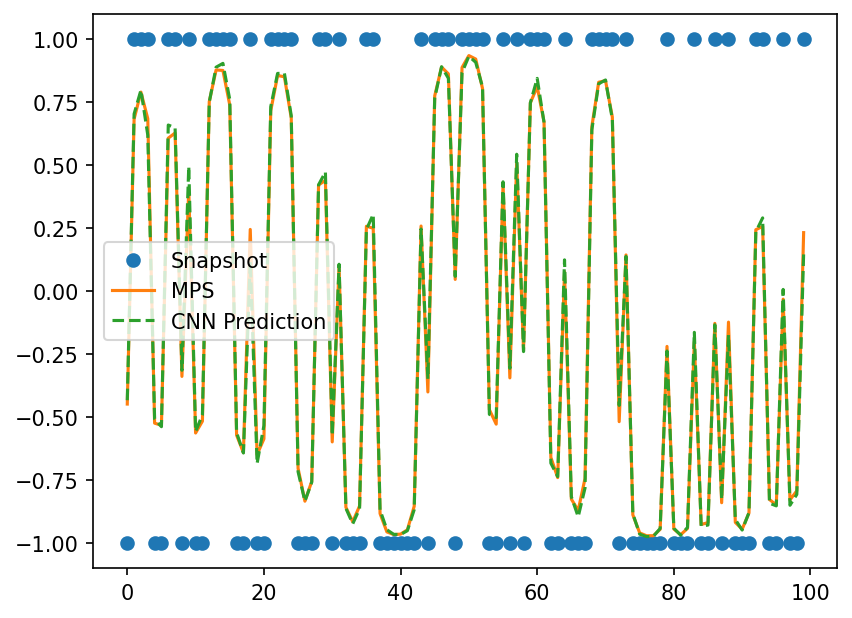

In [70]:
from pathlib import Path
# import MPSToolBox as my

# psi_path = f"../wavefunctions/CritIsingModel_L{L}_chi300_PBC_.pkl"
# psi = my.load_pkl(psi_path)
# gates = [my.expm(beta * s[i] * my.sZ) for i in range(L)]
# psi_measured = my.gate_onsite1(psi, gates, np.arange(L))
# psi_measured.canonical_form()
# Zexp = psi_measured.expectation_value("Sigmaz") # Error due to version mismatch of Tenpy

#random outcome drawn from unifrom distribution over {-1, 1} for each site
s = [-1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, -1, -1, 1]

Zexp = [-0.4477597065443677, 0.683397913100975, 0.7901551600296326, 0.6847145509250216, -0.523585100645727, -0.5320129910246445, 0.6073930817435984, 0.6278879581606998, -0.3380794388206455, 0.40279180020703, -0.5626407935346533, -0.5156309307495777, 0.7521907697114465, 0.8781710054925468, 0.8759323541687234, 0.7392620544739735, -0.57105051547894, -0.6404226791957761, 0.2451988022727719, -0.6483189749357204, -0.5859895436213518, 0.716005322037059, 0.8559151128396354, 0.8509413553521297, 0.6879618787553132, -0.7030656384706745, -0.8332106187159413, -0.7549319162732344, 0.42157097551108413, 0.44003634835695793, -0.5980320684257624, 0.09870433099549844, -0.8572394673954283, -0.914985002887631, -0.8523324222372348, 0.2577030964703095, 0.24999907332567084, -0.8821965252203244, -0.9551079154511115, -0.9657124922035639, -0.963916492981363, -0.9469083577818269, -0.8530519279333771, 0.2587200677377981, -0.39981676924709786, 0.7751865383641937, 0.8894137241825858, 0.8625297899642226, 0.04681933666292786, 0.8877277390019552, 0.9351040287404516, 0.9213292386435912, 0.8041396013811394, -0.4700974385392513, -0.5275017822293762, 0.4249861098579827, -0.34392381557872104, 0.5100733527291691, -0.23494303993575863, 0.7473543447554929, 0.8116469405164825, 0.6722042035406663, -0.6592457524510743, -0.7396629910821028, 0.07717670789716846, -0.8251362988713388, -0.8697577357653855, -0.7433698208764448, 0.6535209836081676, 0.8292636303633969, 0.8354578571159539, 0.6909148418075883, -0.5176842868458882, 0.14402190481987434, -0.887197195000919, -0.9589070063216238, -0.9703863168401434, -0.9701543570341074, -0.9448312774659344, -0.2190018135393509, -0.9438007684296945, -0.9663380339895229, -0.9412690154559513, -0.20075281643404563, -0.925847956464899, -0.9180748601340586, -0.12757503740847018, -0.8393326584504482, -0.12260322418609662, -0.9173833703811438, -0.9443788478832442, -0.8796958018955262, 0.24405423260870468, 0.25722335104420885, -0.8265199475780958, -0.8481058865081772, -0.03147000362415009, -0.8280930760830701, -0.7920116004906036, 0.23245209189114469]

model_path = f"temp/dilatedcnn_L{L}_beta{beta}.pt"
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
# CNN-only prediction
if "model" in globals() and hasattr(model, "eval"):
    with torch.no_grad():
        y_pred = model(torch.from_numpy(x_input)).cpu().numpy()[0]
else:
    ckpt_path = Path(model_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cnn_net = dialtedCNN(
        input_length=int(ckpt["L"]),
        hidden_channels=int(ckpt["hidden_channels"]),
        kernel_size=int(ckpt["kernel_size"]),
        dilation_base=int(ckpt["dilation_base"]),
        num_blocks=int(ckpt["num_blocks"]),
    )
    cnn_net.load_state_dict(ckpt["model_state_dict"])
    cnn_net.eval()
    with torch.no_grad():
        y_pred = cnn_net(torch.from_numpy(x_input)).cpu().numpy()[0]
plt.plot(s, marker="o", linestyle="", label="Snapshot")
plt.plot(Zexp, linestyle="-", label="MPS")
plt.plot(y_pred, linestyle="--", label="CNN Prediction")
plt.legend()


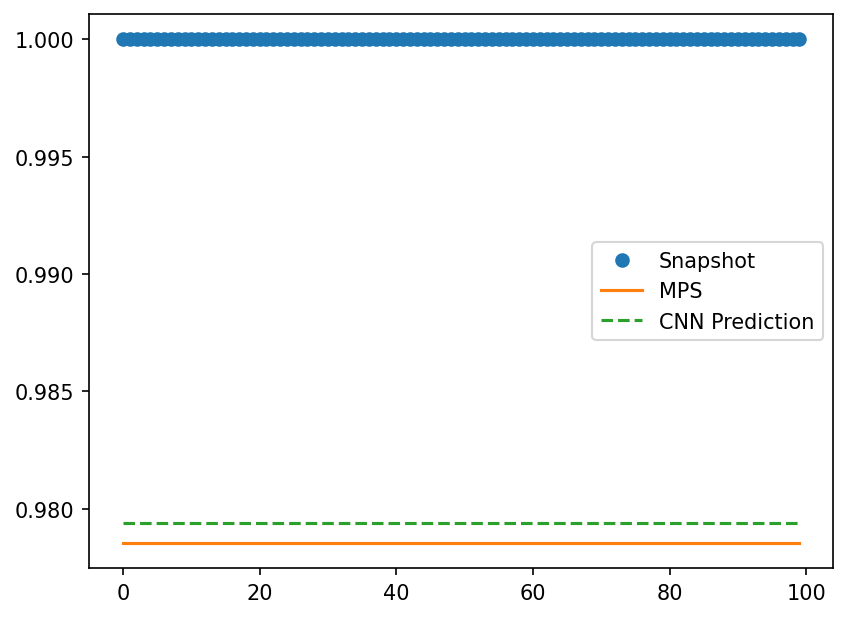

In [71]:
from pathlib import Path
# import MPSToolBox as my

# psi_path = f"../wavefunctions/CritIsingModel_L{L}_chi300_PBC_.pkl"
# psi = my.load_pkl(psi_path)
# gates = [my.expm(beta * s[i] * my.sZ) for i in range(L)]
# psi_measured = my.gate_onsite1(psi, gates, np.arange(L))
# psi_measured.canonical_form()
# Zexp = psi_measured.expectation_value("Sigmaz") # Error due to version mismatch of Tenpy

#random outcome drawn from unifrom distribution over {-1, 1} for each site
s = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Zexp = [0.9785330329770897, 0.9785330317072274, 0.9785330330833323, 0.978533033832604, 0.9785330342671192, 0.978533034538501, 0.9785330347291179, 0.978533034872424, 0.9785330349825677, 0.9785330350675336, 0.9785330351321065, 0.9785330351794939, 0.9785330352129918, 0.9785330352346406, 0.978533035247463, 0.9785330352527704, 0.9785330352509704, 0.9785330352451529, 0.9785330352346483, 0.9785330352207448, 0.9785330352034215, 0.9785330351811575, 0.9785330351544216, 0.9785330351213322, 0.978533035083292, 0.97853303504326, 0.9785330350019269, 0.9785330349440993, 0.9785330348832941, 0.9785330348073857, 0.9785330347330331, 0.9785330346712876, 0.9785330346086966, 0.9785330345516318, 0.9785330344881691, 0.9785330344269992, 0.978533034370212, 0.9785330343155703, 0.9785330342627565, 0.9785330342135949, 0.9785330341681279, 0.9785330341254989, 0.9785330340865022, 0.9785330340519354, 0.9785330340220088, 0.978533033996611, 0.978533033975947, 0.978533033960209, 0.9785330339492276, 0.9785330339435228, 0.9785330339434137, 0.9785330339493795, 0.9785330339599883, 0.9785330339755791, 0.978533033996413, 0.978533034022293, 0.9785330340525685, 0.9785330340871149, 0.9785330341262213, 0.9785330341691758, 0.9785330342150883, 0.9785330342652044, 0.9785330343174233, 0.978533034369858, 0.9785330344257153, 0.9785330344853872, 0.9785330345453321, 0.9785330346061812, 0.9785330346658746, 0.9785330347405373, 0.978533034825297, 0.9785330348999092, 0.9785330349647028, 0.9785330350087071, 0.9785330350528681, 0.9785330350930428, 0.9785330351267175, 0.9785330351575167, 0.9785330351843852, 0.9785330352081181, 0.9785330352271535, 0.9785330352415089, 0.9785330352518721, 0.9785330352577208, 0.9785330352588721, 0.9785330352527419, 0.9785330352391888, 0.9785330352173324, 0.9785330351838328, 0.9785330351363432, 0.9785330350715423, 0.978533034985404, 0.9785330348732554, 0.9785330347276094, 0.9785330345350574, 0.9785330342628238, 0.9785330338295237, 0.9785330330789285, 0.9785330316796951, 0.978533032557889]

model_path = f"temp/dilatedcnn_L{L}_beta{beta}.pt"
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
# CNN-only prediction
if "model" in globals() and hasattr(model, "eval"):
    with torch.no_grad():
        y_pred = model(torch.from_numpy(x_input)).cpu().numpy()[0]
else:
    ckpt_path = Path(model_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cnn_net = dialtedCNN(
        input_length=int(ckpt["L"]),
        hidden_channels=int(ckpt["hidden_channels"]),
        kernel_size=int(ckpt["kernel_size"]),
        dilation_base=int(ckpt["dilation_base"]),
        num_blocks=int(ckpt["num_blocks"]),
    )
    cnn_net.load_state_dict(ckpt["model_state_dict"])
    cnn_net.eval()
    with torch.no_grad():
        y_pred = cnn_net(torch.from_numpy(x_input)).cpu().numpy()[0]
plt.plot(s, marker="o", linestyle="", label="Snapshot")
plt.plot(Zexp, linestyle="-", label="MPS")
plt.plot(y_pred, linestyle="--", label="CNN Prediction")
plt.legend()


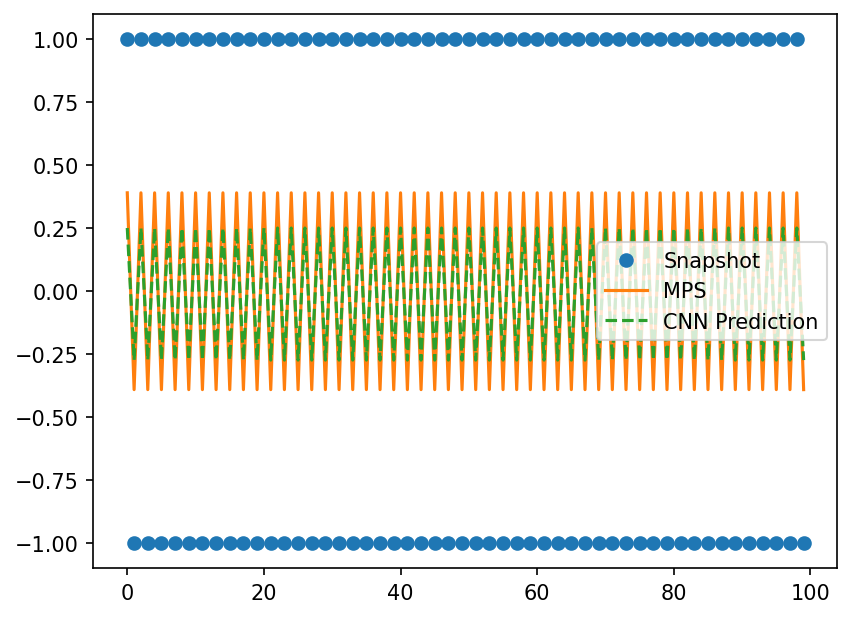

In [72]:
from pathlib import Path
# import MPSToolBox as my

# psi_path = f"../wavefunctions/CritIsingModel_L{L}_chi300_PBC_.pkl"
# psi = my.load_pkl(psi_path)
# gates = [my.expm(beta * s[i] * my.sZ) for i in range(L)]
# psi_measured = my.gate_onsite1(psi, gates, np.arange(L))
# psi_measured.canonical_form()
# Zexp = psi_measured.expectation_value("Sigmaz") # Error due to version mismatch of Tenpy

# Staggered outcome
s = [1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1]


Zexp = [0.3904917756576417, -0.390491787676784, 0.3904917863020419, -0.3904918201928192, 0.3904917702085484, -0.3904917929922959, 0.39049177802835794, -0.39049180127607236, 0.39049176661403595, -0.3904918100215757, 0.39049176331996754, -0.3904918071225197, 0.3904917695282345, -0.3904917977343353, 0.3904917792702709, -0.3904917882202257, 0.3904917875705698, -0.390491781780521, 0.39049179316423666, -0.3904917782684219, 0.3904917957767333, -0.3904917776354726, 0.39049179632718967, -0.3904917786713529, 0.390491796652726, -0.39049177891944803, 0.3904917964843481, -0.39049177969007653, 0.3904917966838737, -0.3904917818690431, 0.3904917969856229, -0.39049178372603205, 0.3904917974822171, -0.3904917858233849, 0.3904917995458238, -0.390491787726089, 0.39049180049061843, -0.39049178991069927, 0.39049180098133884, -0.3904917924787941, 0.39049180113110815, -0.39049179490345837, 0.39049180124960997, -0.39049179686055413, 0.39049180135082967, -0.3904917983019828, 0.3904918013477452, -0.3904917993797091, 0.39049180104725834, -0.3904918002365178, 0.39049180028311825, -0.39049180106867526, 0.3904917988838028, -0.3904918019762164, 0.3904917967749906, -0.3904918029830832, 0.3904917940629395, -0.390491803806334, 0.39049179127743683, -0.3904918038563018, 0.39049178909510496, -0.3904918029309394, 0.3904917868586313, -0.39049180102373376, 0.3904917840802638, -0.3904917994030798, 0.39049178144549257, -0.39049179898862846, 0.39049178065641343, -0.39049179866133715, 0.39049177955461634, -0.3904917971993995, 0.39049177896132603, -0.39049179743360435, 0.39049177805418284, -0.39049179820720953, 0.39049177660451784, -0.3904917979077698, 0.3904917762208285, -0.39049179687461133, 0.3904917773844519, -0.39049179380515087, 0.39049178052751066, -0.3904917886369514, 0.3904917864206056, -0.39049178135434853, 0.3904917945021682, -0.3904917734826549, 0.3904918022109227, -0.39049176858151313, 0.390491804836859, -0.3904917710550076, 0.39049179760227226, -0.3904917807052185, 0.39049178957628294, -0.3904917743930922, 0.3904918128651737, -0.39049179522387545, 0.3904917805038864, -0.390491781252008]

model_path = f"temp/dilatedcnn_L{L}_beta{beta}.pt"
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
# CNN-only prediction
if "model" in globals() and hasattr(model, "eval"):
    with torch.no_grad():
        y_pred = model(torch.from_numpy(x_input)).cpu().numpy()[0]
else:
    ckpt_path = Path(model_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cnn_net = dialtedCNN(
        input_length=int(ckpt["L"]),
        hidden_channels=int(ckpt["hidden_channels"]),
        kernel_size=int(ckpt["kernel_size"]),
        dilation_base=int(ckpt["dilation_base"]),
        num_blocks=int(ckpt["num_blocks"]),
    )
    cnn_net.load_state_dict(ckpt["model_state_dict"])
    cnn_net.eval()
    with torch.no_grad():
        y_pred = cnn_net(torch.from_numpy(x_input)).cpu().numpy()[0]
plt.plot(s, marker="o", linestyle="", label="Snapshot")
plt.plot(Zexp, linestyle="-", label="MPS")
plt.plot(y_pred, linestyle="--", label="CNN Prediction")
plt.legend()


## Use whole data for training.

We now use the whole dataset for training and return

In [73]:
L = 100 # system size
beta = 0.5
N = 100000 # number of snapshots
X = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")[:N] # shape: (N, L), where N is the number of snapshots and L is the system size
Y = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")[:N] # shape: (N, L), where N is the number of snapshots and L is the system size


from pathlib import Path
X_all = np.asarray(X, dtype=np.float32)
Y_all = np.asarray(Y, dtype=np.float32)
if X_all.shape != Y_all.shape:
    raise ValueError(f"Shape mismatch: X{X_all.shape} vs Y{Y_all.shape}")
save_dir = Path("temp")
save_dir.mkdir(parents=True, exist_ok=True)
models_all = {
    "Linear": myLinearRegressionModel(
        fit_intercept=True,
        pbc_shared=True,
        augment_z2=True,
        seed=0,
        verbose=0,
    ),
    "Logistic": myLogisticRegressionModel(
        solver="lbfgs",
        C=1.0,
        max_iter=400,
        fit_intercept=True,
        pbc_shared=True,
        augment_z2=True,
        seed=0,
        verbose=0,
    ),
    "CNN": dilatedCNNModel(
        hidden_channels=64,
        kernel_size=3,
        dilation_base=2,
        num_blocks=None,
        lr=1e-3,
        batch_size=256,
        epochs=20,
        augment_z2=True,
        seed=0,
        verbose=0,
    ),
}
save_paths = {
    "Linear": save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{X_all.shape[0]}.pkl",
    "Logistic": save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{X_all.shape[0]}.pkl",
    "CNN": save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{X_all.shape[0]}.pt",
}
train_mse_all = {}
for name in ["Linear", "Logistic", "CNN"]:
    mdl = models_all[name]
    mdl.fit(X_all, Y_all, val_split=0.0, plot=False)
    train_mse_all[name] = mdl.score(X_all, Y_all, metric="mse")
    mdl.save(save_paths[name])
    print(f"Saved {name} model to: {save_paths[name]}")
print("\nTraining MSE on full dataset:")
for name in ["Linear", "Logistic", "CNN"]:
    print(f"{name}: {train_mse_all[name]:.6f}")


Saved Linear model to: temp/linear_sharedpbc_L100_beta0.5_N100000.pkl
Saved Logistic model to: temp/logistic_sharedpbc_L100_beta0.5_N100000.pkl
Saved CNN model to: temp/dilatedcnn_sharedpbc_L100_beta0.5_N100000.pt

Training MSE on full dataset:
Linear: 0.299015
Logistic: 0.285121
CNN: 0.281137


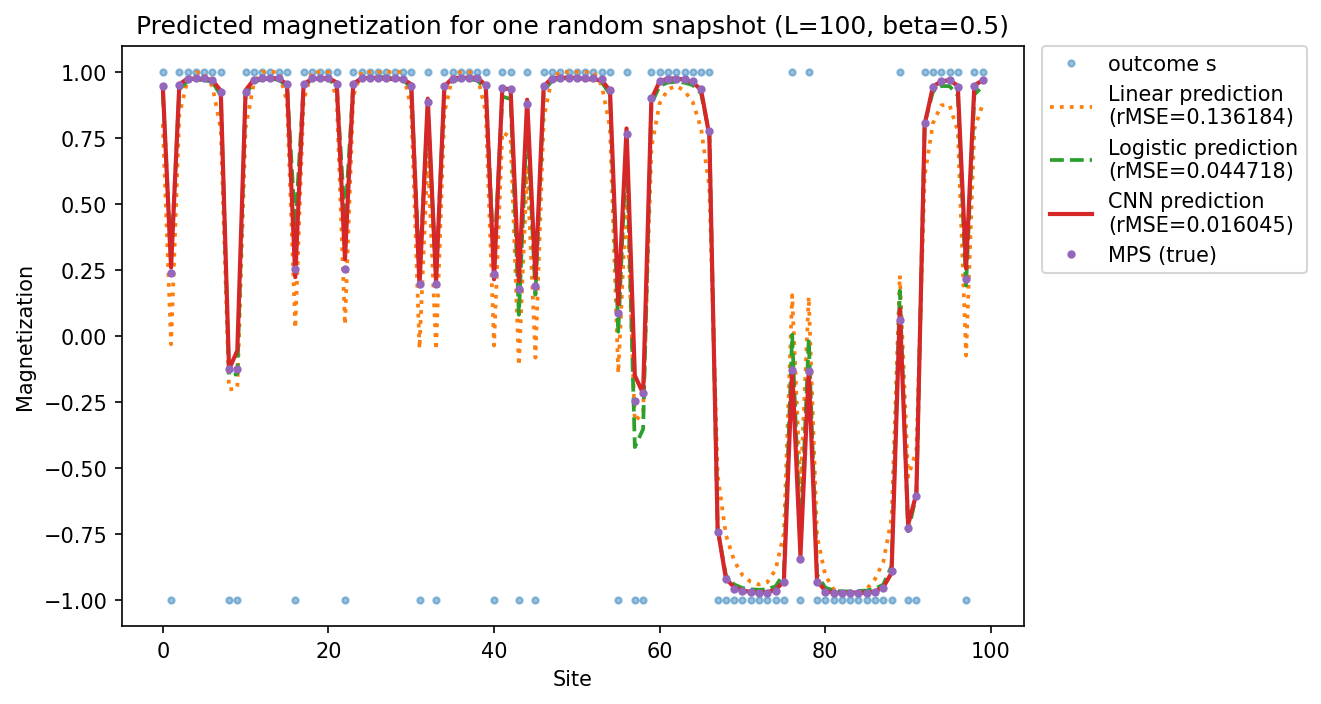

In [91]:
L = 100
beta = 0.5
N = 100000
# measurement outcome from training set
s = [1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1, 1]

Zexp = [0.9482362036114398, 0.23726664087863517, 0.951143756044781, 0.9744796335090715, 0.9767762113870042, 0.9761391867035544, 0.970431142602581, 0.9220727064712133, -0.1257287648832543, -0.12541858211094112, 0.9225576299527822, 0.970746008454795, 0.9764438016700304, 0.9771918802575102, 0.9752855562190098, 0.953759864604575, 0.25181577412216183, 0.9538846775353867, 0.9754008089529851, 0.9772362561824438, 0.9754544508305469, 0.9541277882993091, 0.25335247377280334, 0.9542786315895514, 0.9756728473256505, 0.9778268125859532, 0.9781609739695802, 0.978105707217673, 0.9775763753908869, 0.9746607856682393, 0.9483380395909897, 0.19712765258496942, 0.88453859463925, 0.19675073135858864, 0.9481276072398767, 0.9744908914261697, 0.9773054603423872, 0.9773855426186121, 0.9750009619391645, 0.9516525902719117, 0.23445250802625794, 0.9404425080744849, 0.9355556358096131, 0.17910968377205852, 0.8776551631337357, 0.1888001814810263, 0.9468195742940898, 0.9741829990316342, 0.9772823005935731, 0.9778252085550106, 0.9778432040419444, 0.9775286790610265, 0.976392345215821, 0.9712241549988658, 0.9325307502553011, 0.0872344622195817, 0.7658717958039966, -0.24713530308096313, -0.21815734832214895, 0.9017156800182479, 0.9642340166564863, 0.9726581033482748, 0.9735924617233763, 0.9715942520220509, 0.9641418744114274, 0.9345743758569875, 0.7745524371295222, -0.7437776447588489, -0.9226493848561353, -0.9588483329410498, -0.9688228401699718, -0.9722823696502053, -0.9734634825904503, -0.9729825537829446, -0.968086687106486, -0.9318587419952717, -0.13135252995543958, -0.844446035241192, -0.13440649651053685, -0.9337352475966411, -0.9693888707555797, -0.9743633275010034, -0.9753693967200323, -0.9754006497301557, -0.9748773337670862, -0.9735256870701442, -0.9699248637506712, -0.9573600640676809, -0.8903964036372046, 0.05803075805834255, -0.729997722318278, -0.608258618645825, 0.8066167734398423, 0.9411576656263829, 0.9647662015524862, 0.9674673521098078, 0.9425299970511741, 0.2160035079710859, 0.9450939242826669, 0.9687333096402221]
from pathlib import Path
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
y_pred = {}
# Prefer in-memory fitted models from the full-data training cell.
if "models_all" in globals() and isinstance(models_all, dict):
    for name in ["Linear", "Logistic", "CNN"]:
        mdl = models_all.get(name, None)
        if mdl is not None and hasattr(mdl, "predict_magnetization"):
            y_pred[name] = mdl.predict_magnetization(x_input)[0]
# Fallback: load saved models if needed.
save_dir = Path("temp")
lin_path = save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
log_path = save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{N}.pt"
if "Linear" not in y_pred:
    if not lin_path.exists():
        raise FileNotFoundError(f"Linear checkpoint not found: {lin_path}")
    lin_model = myLinearRegressionModel.load(lin_path)
    y_pred["Linear"] = lin_model.predict_magnetization(x_input)[0]
if "Logistic" not in y_pred:
    if not log_path.exists():
        raise FileNotFoundError(f"Logistic checkpoint not found: {log_path}")
    log_model = myLogisticRegressionModel.load(log_path)
    y_pred["Logistic"] = log_model.predict_magnetization(x_input)[0]
if "CNN" not in y_pred:
    if not cnn_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {cnn_path}")
    cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
    y_pred["CNN"] = cnn_model.predict_magnetization(x_input)[0]
z_true = np.asarray(Zexp, dtype=np.float32)
rmse_linear = float(np.sqrt(np.mean((y_pred["Linear"] - z_true) ** 2)))
rmse_logistic = float(np.sqrt(np.mean((y_pred["Logistic"] - z_true) ** 2)))
rmse_cnn = float(np.sqrt(np.mean((y_pred["CNN"] - z_true) ** 2)))
plt.figure(figsize=(11.5, 4.8))
plt.plot(s, marker="o", linestyle="", markersize=3, alpha=0.45, label="outcome s")
plt.plot(y_pred["Linear"], linestyle=":", linewidth=1.8, label=f"Linear prediction\n(rMSE={rmse_linear:.6f})")
plt.plot(y_pred["Logistic"], linestyle="--", linewidth=1.8, label=f"Logistic prediction\n(rMSE={rmse_logistic:.6f})")
plt.plot(y_pred["CNN"], linestyle="-", linewidth=2.0, label=f"CNN prediction\n(rMSE={rmse_cnn:.6f})")
plt.plot(z_true, marker=".", linestyle="", linewidth=1.8, label="MPS (true)")
plt.xlabel("Site")
plt.ylabel("Magnetization")
plt.title(f"Predicted magnetization for one random snapshot (L={L}, beta={beta})")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


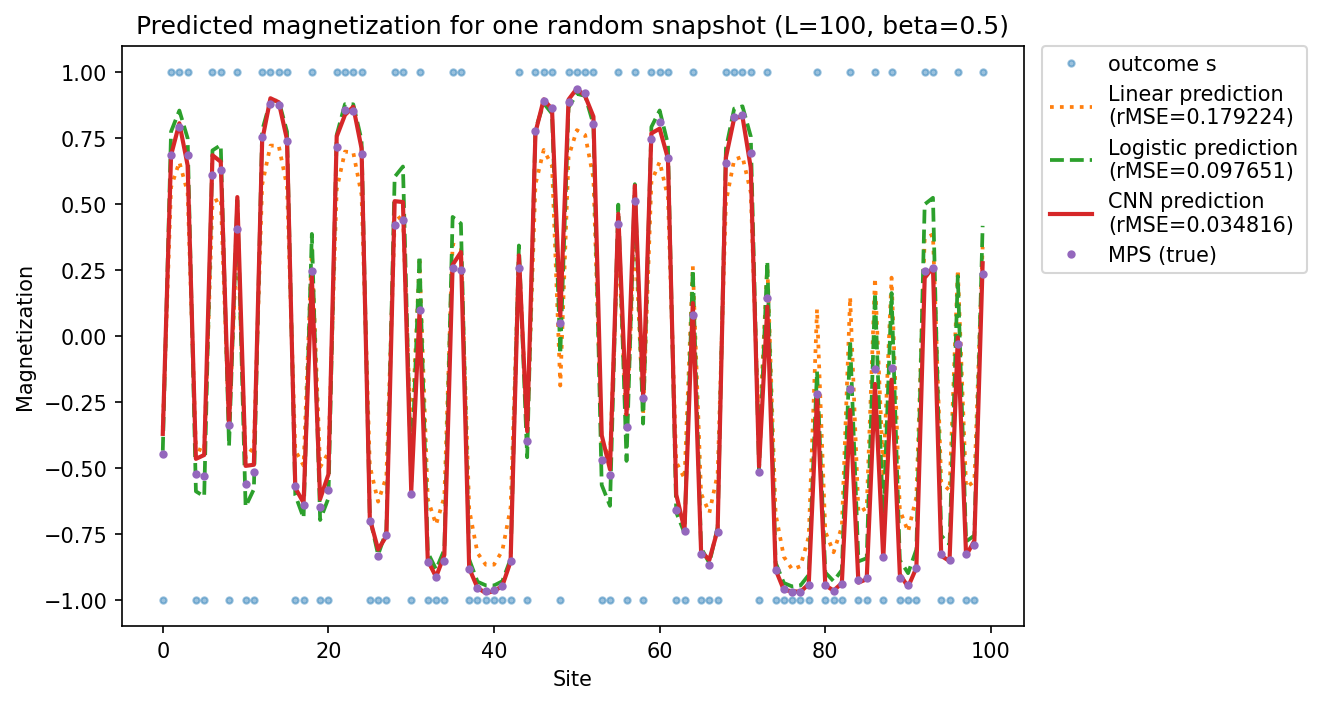

In [90]:
L = 100
beta = 0.5
N = 100000
# random outcome drawn from unifrom distribution over {-1, 1} for each site
s = [-1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, -1, -1, 1]
Zexp = [-0.4477597065443677, 0.683397913100975, 0.7901551600296326, 0.6847145509250216, -0.523585100645727, -0.5320129910246445, 0.6073930817435984, 0.6278879581606998, -0.3380794388206455, 0.40279180020703, -0.5626407935346533, -0.5156309307495777, 0.7521907697114465, 0.8781710054925468, 0.8759323541687234, 0.7392620544739735, -0.57105051547894, -0.6404226791957761, 0.2451988022727719, -0.6483189749357204, -0.5859895436213518, 0.716005322037059, 0.8559151128396354, 0.8509413553521297, 0.6879618787553132, -0.7030656384706745, -0.8332106187159413, -0.7549319162732344, 0.42157097551108413, 0.44003634835695793, -0.5980320684257624, 0.09870433099549844, -0.8572394673954283, -0.914985002887631, -0.8523324222372348, 0.2577030964703095, 0.24999907332567084, -0.8821965252203244, -0.9551079154511115, -0.9657124922035639, -0.963916492981363, -0.9469083577818269, -0.8530519279333771, 0.2587200677377981, -0.39981676924709786, 0.7751865383641937, 0.8894137241825858, 0.8625297899642226, 0.04681933666292786, 0.8877277390019552, 0.9351040287404516, 0.9213292386435912, 0.8041396013811394, -0.4700974385392513, -0.5275017822293762, 0.4249861098579827, -0.34392381557872104, 0.5100733527291691, -0.23494303993575863, 0.7473543447554929, 0.8116469405164825, 0.6722042035406663, -0.6592457524510743, -0.7396629910821028, 0.07717670789716846, -0.8251362988713388, -0.8697577357653855, -0.7433698208764448, 0.6535209836081676, 0.8292636303633969, 0.8354578571159539, 0.6909148418075883, -0.5176842868458882, 0.14402190481987434, -0.887197195000919, -0.9589070063216238, -0.9703863168401434, -0.9701543570341074, -0.9448312774659344, -0.2190018135393509, -0.9438007684296945, -0.9663380339895229, -0.9412690154559513, -0.20075281643404563, -0.925847956464899, -0.9180748601340586, -0.12757503740847018, -0.8393326584504482, -0.12260322418609662, -0.9173833703811438, -0.9443788478832442, -0.8796958018955262, 0.24405423260870468, 0.25722335104420885, -0.8265199475780958, -0.8481058865081772, -0.03147000362415009, -0.8280930760830701, -0.7920116004906036, 0.23245209189114469]
from pathlib import Path
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
y_pred = {}
# Prefer in-memory fitted models from the full-data training cell.
if "models_all" in globals() and isinstance(models_all, dict):
    for name in ["Linear", "Logistic", "CNN"]:
        mdl = models_all.get(name, None)
        if mdl is not None and hasattr(mdl, "predict_magnetization"):
            y_pred[name] = mdl.predict_magnetization(x_input)[0]
# Fallback: load saved models if needed.
save_dir = Path("temp")
lin_path = save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
log_path = save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{N}.pt"
if "Linear" not in y_pred:
    if not lin_path.exists():
        raise FileNotFoundError(f"Linear checkpoint not found: {lin_path}")
    lin_model = myLinearRegressionModel.load(lin_path)
    y_pred["Linear"] = lin_model.predict_magnetization(x_input)[0]
if "Logistic" not in y_pred:
    if not log_path.exists():
        raise FileNotFoundError(f"Logistic checkpoint not found: {log_path}")
    log_model = myLogisticRegressionModel.load(log_path)
    y_pred["Logistic"] = log_model.predict_magnetization(x_input)[0]
if "CNN" not in y_pred:
    if not cnn_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {cnn_path}")
    cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
    y_pred["CNN"] = cnn_model.predict_magnetization(x_input)[0]
z_true = np.asarray(Zexp, dtype=np.float32)
rmse_linear = float(np.sqrt(np.mean((y_pred["Linear"] - z_true) ** 2)))
rmse_logistic = float(np.sqrt(np.mean((y_pred["Logistic"] - z_true) ** 2)))
rmse_cnn = float(np.sqrt(np.mean((y_pred["CNN"] - z_true) ** 2)))
plt.figure(figsize=(11.5, 4.8))
plt.plot(s, marker="o", linestyle="", markersize=3, alpha=0.45, label="outcome s")
plt.plot(y_pred["Linear"], linestyle=":", linewidth=1.8, label=f"Linear prediction\n(rMSE={rmse_linear:.6f})")
plt.plot(y_pred["Logistic"], linestyle="--", linewidth=1.8, label=f"Logistic prediction\n(rMSE={rmse_logistic:.6f})")
plt.plot(y_pred["CNN"], linestyle="-", linewidth=2.0, label=f"CNN prediction\n(rMSE={rmse_cnn:.6f})")
plt.plot(z_true, marker=".", linestyle="", linewidth=1.8, label="MPS (true)")
plt.xlabel("Site")
plt.ylabel("Magnetization")
plt.title(f"Predicted magnetization for one random snapshot (L={L}, beta={beta})")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


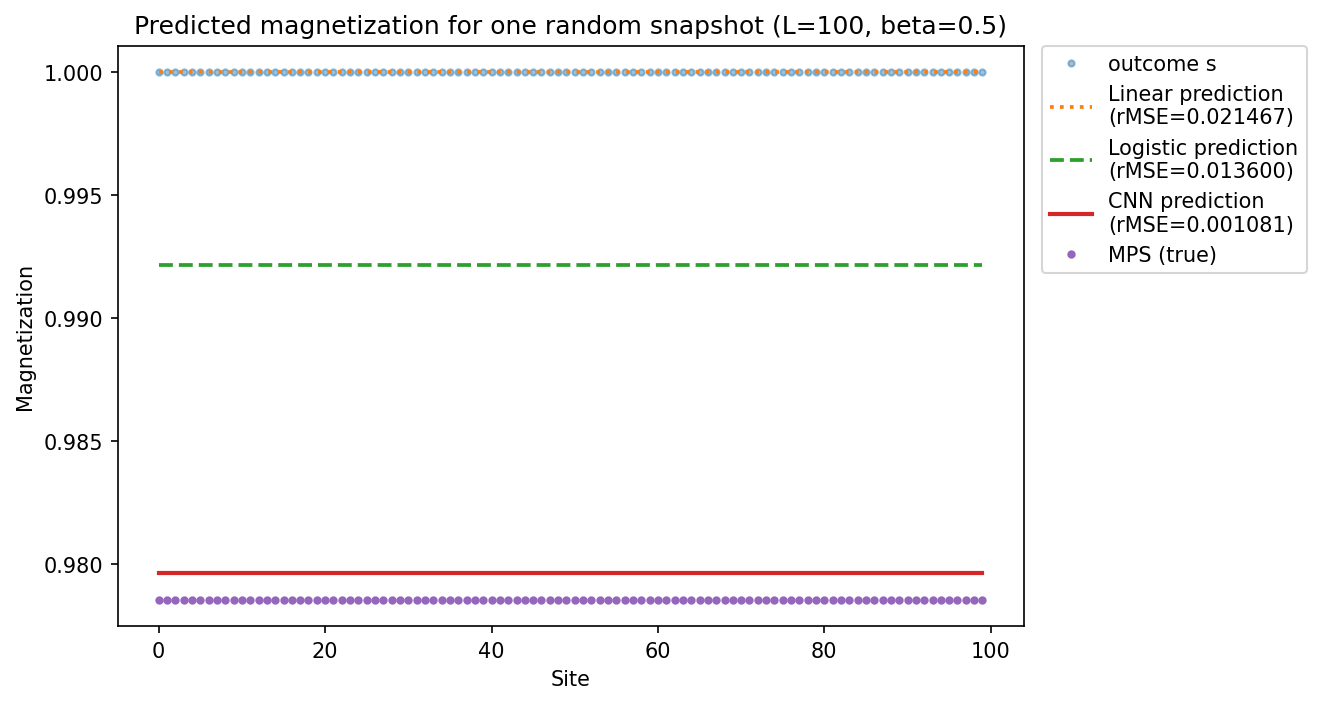

In [92]:
L = 100
beta = 0.5
N = 100000
#random outcome drawn from unifrom distribution over {-1, 1} for each site
s = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Zexp = [0.9785330329770897, 0.9785330317072274, 0.9785330330833323, 0.978533033832604, 0.9785330342671192, 0.978533034538501, 0.9785330347291179, 0.978533034872424, 0.9785330349825677, 0.9785330350675336, 0.9785330351321065, 0.9785330351794939, 0.9785330352129918, 0.9785330352346406, 0.978533035247463, 0.9785330352527704, 0.9785330352509704, 0.9785330352451529, 0.9785330352346483, 0.9785330352207448, 0.9785330352034215, 0.9785330351811575, 0.9785330351544216, 0.9785330351213322, 0.978533035083292, 0.97853303504326, 0.9785330350019269, 0.9785330349440993, 0.9785330348832941, 0.9785330348073857, 0.9785330347330331, 0.9785330346712876, 0.9785330346086966, 0.9785330345516318, 0.9785330344881691, 0.9785330344269992, 0.978533034370212, 0.9785330343155703, 0.9785330342627565, 0.9785330342135949, 0.9785330341681279, 0.9785330341254989, 0.9785330340865022, 0.9785330340519354, 0.9785330340220088, 0.978533033996611, 0.978533033975947, 0.978533033960209, 0.9785330339492276, 0.9785330339435228, 0.9785330339434137, 0.9785330339493795, 0.9785330339599883, 0.9785330339755791, 0.978533033996413, 0.978533034022293, 0.9785330340525685, 0.9785330340871149, 0.9785330341262213, 0.9785330341691758, 0.9785330342150883, 0.9785330342652044, 0.9785330343174233, 0.978533034369858, 0.9785330344257153, 0.9785330344853872, 0.9785330345453321, 0.9785330346061812, 0.9785330346658746, 0.9785330347405373, 0.978533034825297, 0.9785330348999092, 0.9785330349647028, 0.9785330350087071, 0.9785330350528681, 0.9785330350930428, 0.9785330351267175, 0.9785330351575167, 0.9785330351843852, 0.9785330352081181, 0.9785330352271535, 0.9785330352415089, 0.9785330352518721, 0.9785330352577208, 0.9785330352588721, 0.9785330352527419, 0.9785330352391888, 0.9785330352173324, 0.9785330351838328, 0.9785330351363432, 0.9785330350715423, 0.978533034985404, 0.9785330348732554, 0.9785330347276094, 0.9785330345350574, 0.9785330342628238, 0.9785330338295237, 0.9785330330789285, 0.9785330316796951, 0.978533032557889]
from pathlib import Path
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
y_pred = {}
# Prefer in-memory fitted models from the full-data training cell.
if "models_all" in globals() and isinstance(models_all, dict):
    for name in ["Linear", "Logistic", "CNN"]:
        mdl = models_all.get(name, None)
        if mdl is not None and hasattr(mdl, "predict_magnetization"):
            y_pred[name] = mdl.predict_magnetization(x_input)[0]
# Fallback: load saved models if needed.
save_dir = Path("temp")
lin_path = save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
log_path = save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{N}.pt"
if "Linear" not in y_pred:
    if not lin_path.exists():
        raise FileNotFoundError(f"Linear checkpoint not found: {lin_path}")
    lin_model = myLinearRegressionModel.load(lin_path)
    y_pred["Linear"] = lin_model.predict_magnetization(x_input)[0]
if "Logistic" not in y_pred:
    if not log_path.exists():
        raise FileNotFoundError(f"Logistic checkpoint not found: {log_path}")
    log_model = myLogisticRegressionModel.load(log_path)
    y_pred["Logistic"] = log_model.predict_magnetization(x_input)[0]
if "CNN" not in y_pred:
    if not cnn_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {cnn_path}")
    cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
    y_pred["CNN"] = cnn_model.predict_magnetization(x_input)[0]
z_true = np.asarray(Zexp, dtype=np.float32)
rmse_linear = float(np.sqrt(np.mean((y_pred["Linear"] - z_true) ** 2)))
rmse_logistic = float(np.sqrt(np.mean((y_pred["Logistic"] - z_true) ** 2)))
rmse_cnn = float(np.sqrt(np.mean((y_pred["CNN"] - z_true) ** 2)))
plt.figure(figsize=(11.5, 4.8))
plt.plot(s, marker="o", linestyle="", markersize=3, alpha=0.45, label="outcome s")
plt.plot(y_pred["Linear"], linestyle=":", linewidth=1.8, label=f"Linear prediction\n(rMSE={rmse_linear:.6f})")
plt.plot(y_pred["Logistic"], linestyle="--", linewidth=1.8, label=f"Logistic prediction\n(rMSE={rmse_logistic:.6f})")
plt.plot(y_pred["CNN"], linestyle="-", linewidth=2.0, label=f"CNN prediction\n(rMSE={rmse_cnn:.6f})")
plt.plot(z_true, marker=".", linestyle="", linewidth=1.8, label="MPS (true)")
plt.xlabel("Site")
plt.ylabel("Magnetization")
plt.title(f"Predicted magnetization for one random snapshot (L={L}, beta={beta})")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


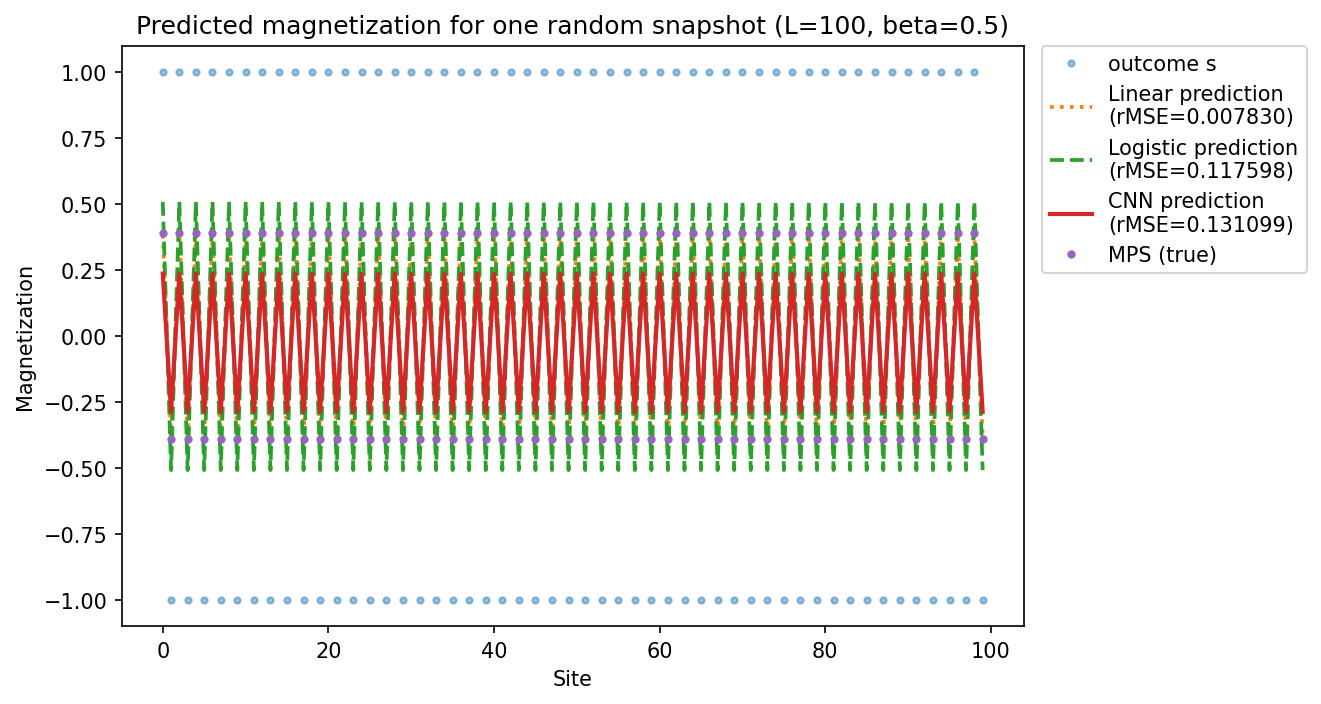

In [93]:
L = 100
beta = 0.5
N = 100000
# Staggered outcome
s = [1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1]


Zexp = [0.3904917756576417, -0.390491787676784, 0.3904917863020419, -0.3904918201928192, 0.3904917702085484, -0.3904917929922959, 0.39049177802835794, -0.39049180127607236, 0.39049176661403595, -0.3904918100215757, 0.39049176331996754, -0.3904918071225197, 0.3904917695282345, -0.3904917977343353, 0.3904917792702709, -0.3904917882202257, 0.3904917875705698, -0.390491781780521, 0.39049179316423666, -0.3904917782684219, 0.3904917957767333, -0.3904917776354726, 0.39049179632718967, -0.3904917786713529, 0.390491796652726, -0.39049177891944803, 0.3904917964843481, -0.39049177969007653, 0.3904917966838737, -0.3904917818690431, 0.3904917969856229, -0.39049178372603205, 0.3904917974822171, -0.3904917858233849, 0.3904917995458238, -0.390491787726089, 0.39049180049061843, -0.39049178991069927, 0.39049180098133884, -0.3904917924787941, 0.39049180113110815, -0.39049179490345837, 0.39049180124960997, -0.39049179686055413, 0.39049180135082967, -0.3904917983019828, 0.3904918013477452, -0.3904917993797091, 0.39049180104725834, -0.3904918002365178, 0.39049180028311825, -0.39049180106867526, 0.3904917988838028, -0.3904918019762164, 0.3904917967749906, -0.3904918029830832, 0.3904917940629395, -0.390491803806334, 0.39049179127743683, -0.3904918038563018, 0.39049178909510496, -0.3904918029309394, 0.3904917868586313, -0.39049180102373376, 0.3904917840802638, -0.3904917994030798, 0.39049178144549257, -0.39049179898862846, 0.39049178065641343, -0.39049179866133715, 0.39049177955461634, -0.3904917971993995, 0.39049177896132603, -0.39049179743360435, 0.39049177805418284, -0.39049179820720953, 0.39049177660451784, -0.3904917979077698, 0.3904917762208285, -0.39049179687461133, 0.3904917773844519, -0.39049179380515087, 0.39049178052751066, -0.3904917886369514, 0.3904917864206056, -0.39049178135434853, 0.3904917945021682, -0.3904917734826549, 0.3904918022109227, -0.39049176858151313, 0.390491804836859, -0.3904917710550076, 0.39049179760227226, -0.3904917807052185, 0.39049178957628294, -0.3904917743930922, 0.3904918128651737, -0.39049179522387545, 0.3904917805038864, -0.390491781252008]
from pathlib import Path
x_input = np.asarray(s, dtype=np.float32).reshape(1, -1)
y_pred = {}
# Prefer in-memory fitted models from the full-data training cell.
if "models_all" in globals() and isinstance(models_all, dict):
    for name in ["Linear", "Logistic", "CNN"]:
        mdl = models_all.get(name, None)
        if mdl is not None and hasattr(mdl, "predict_magnetization"):
            y_pred[name] = mdl.predict_magnetization(x_input)[0]
# Fallback: load saved models if needed.
save_dir = Path("temp")
lin_path = save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
log_path = save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{N}.pkl"
cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{N}.pt"
if "Linear" not in y_pred:
    if not lin_path.exists():
        raise FileNotFoundError(f"Linear checkpoint not found: {lin_path}")
    lin_model = myLinearRegressionModel.load(lin_path)
    y_pred["Linear"] = lin_model.predict_magnetization(x_input)[0]
if "Logistic" not in y_pred:
    if not log_path.exists():
        raise FileNotFoundError(f"Logistic checkpoint not found: {log_path}")
    log_model = myLogisticRegressionModel.load(log_path)
    y_pred["Logistic"] = log_model.predict_magnetization(x_input)[0]
if "CNN" not in y_pred:
    if not cnn_path.exists():
        raise FileNotFoundError(f"CNN checkpoint not found: {cnn_path}")
    cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
    y_pred["CNN"] = cnn_model.predict_magnetization(x_input)[0]
z_true = np.asarray(Zexp, dtype=np.float32)
rmse_linear = float(np.sqrt(np.mean((y_pred["Linear"] - z_true) ** 2)))
rmse_logistic = float(np.sqrt(np.mean((y_pred["Logistic"] - z_true) ** 2)))
rmse_cnn = float(np.sqrt(np.mean((y_pred["CNN"] - z_true) ** 2)))
plt.figure(figsize=(11.5, 4.8))
plt.plot(s, marker="o", linestyle="", markersize=3, alpha=0.45, label="outcome s")
plt.plot(y_pred["Linear"], linestyle=":", linewidth=1.8, label=f"Linear prediction\n(rMSE={rmse_linear:.6f})")
plt.plot(y_pred["Logistic"], linestyle="--", linewidth=1.8, label=f"Logistic prediction\n(rMSE={rmse_logistic:.6f})")
plt.plot(y_pred["CNN"], linestyle="-", linewidth=2.0, label=f"CNN prediction\n(rMSE={rmse_cnn:.6f})")
plt.plot(z_true, marker=".", linestyle="", linewidth=1.8, label="MPS (true)")
plt.xlabel("Site")
plt.ylabel("Magnetization")
plt.title(f"Predicted magnetization for one random snapshot (L={L}, beta={beta})")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


## Predict Y from X

In [9]:
import matplotlib.pyplot as plt

In [2]:
L = 100 # system size
beta = 0.5
N = 100000 # number of snapshots
X = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")[:N] # shape: (N, L), where N is the number of snapshots and L is the system size
Y = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")[:N] # shape: (N, L), where N is the number of snapshots and L is the system size

In [95]:
from pathlib import Path
X_input = np.asarray(X, dtype=np.float32)
save_dir = Path("temp")
save_dir.mkdir(parents=True, exist_ok=True)
model_paths = {
    "Linear": save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{X_input.shape[0]}.pkl",
    "Logistic": save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{X_input.shape[0]}.pkl",
    "CNN": save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{X_input.shape[0]}.pt",
}
pred_paths = {
    "Linear": save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N{X_input.shape[0]}_y_pred.npy",
    "Logistic": save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N{X_input.shape[0]}_y_pred.npy",
    "CNN": save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N{X_input.shape[0]}_y_pred.npy",
}
loaded_models = {}
if "models_all" in globals() and isinstance(models_all, dict):
    loaded_models.update({k: v for k, v in models_all.items() if k in ["Linear", "Logistic", "CNN"]})
if "Linear" not in loaded_models:
    if not model_paths["Linear"].exists():
        raise FileNotFoundError(f"Linear model checkpoint not found: {model_paths['Linear']}")
    loaded_models["Linear"] = myLinearRegressionModel.load(model_paths["Linear"])
if "Logistic" not in loaded_models:
    if not model_paths["Logistic"].exists():
        raise FileNotFoundError(f"Logistic model checkpoint not found: {model_paths['Logistic']}")
    loaded_models["Logistic"] = myLogisticRegressionModel.load(model_paths["Logistic"])
if "CNN" not in loaded_models:
    if not model_paths["CNN"].exists():
        raise FileNotFoundError(f"CNN model checkpoint not found: {model_paths['CNN']}")
    loaded_models["CNN"] = dilatedCNNModel.load(model_paths["CNN"], map_location="cpu")
Y_pred_all = {}
for name in ["Linear", "Logistic", "CNN"]:
    y_pred = loaded_models[name].predict_magnetization(X_input).astype(np.float32)
    Y_pred_all[name] = y_pred
    np.save(pred_paths[name], y_pred)
    print(f"Saved {name} predictions: {pred_paths[name]} | shape={y_pred.shape}")


Saved Linear predictions: temp/linear_sharedpbc_L100_beta0.5_N100000_y_pred.npy | shape=(100000, 100)
Saved Logistic predictions: temp/logistic_sharedpbc_L100_beta0.5_N100000_y_pred.npy | shape=(100000, 100)
Saved CNN predictions: temp/dilatedcnn_sharedpbc_L100_beta0.5_N100000_y_pred.npy | shape=(100000, 100)


In [3]:
Y_pred = np.load("temp/dilatedcnn_sharedpbc_L100_beta0.5_N100000_y_pred.npy")

/tmp/ipykernel_3733645/137155625.py:38: RuntimeWarning: divide by zero encountered in power
  fitted_line = np.exp(polynomial_fit[1]) * r_chord ** polynomial_fit[0]


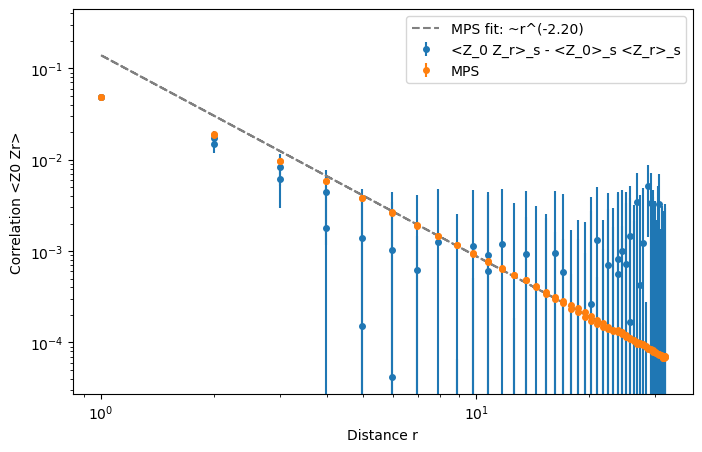

In [67]:
r_list = np.arange(L)
Zcorr_data = []
Zcorr_data_std = []
for i in r_list:
    Zcorr = np.mean(Y[:,0] * Y[:, i])
    Zcorr_std = np.std(Y[:,0] * Y[:, i]) / np.sqrt(Y.shape[0])
    Zcorr_data.append(Zcorr)
    Zcorr_data_std.append(Zcorr_std)
Z0Zr_pred = []
Z0Zr_pred_std = []
for r in r_list:
    Z0Zr_pred.append(np.mean(Y_pred[:,0] * Y_pred[:,r]))
    Z0Zr_pred_std.append(np.std(Y_pred[:,0] * Y_pred[:,r]) / np.sqrt(Y_pred.shape[0]))
Z0Zr_pred = np.array(Z0Zr_pred)
Z0Zr_pred_std = np.array(Z0Zr_pred_std)
Zcorr_data = np.array(Zcorr_data)
Zcorr_data_std = np.array(Zcorr_data_std)

def mps_data(q=1):
    Zcorr = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zcorr_N10000_0_r.npy")
    # load <Z_r>_s, where each row corresponds to a different snapshot and each column corresponds to a different position r.
    Z = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")

    _connected_corr = Zcorr - Z[:, :1] * Z
    return np.mean(np.power(np.abs(_connected_corr), q), axis=0), np.std(np.power(np.abs(_connected_corr), q), axis=0)/np.sqrt(Z.shape[0])
y_mps, y_mps_std = mps_data(q=1)


plt.figure(figsize=(8, 5))
plt.errorbar(r_chord, Zcorr_data - Z0Zr_pred, yerr=np.sqrt(Zcorr_data_std**2 + Z0Zr_pred_std**2), fmt="o", markersize=4, label="<Z_0 Z_r>_s - <Z_0>_s <Z_r>_s")
plt.errorbar(r_chord, y_mps, yerr=np.sqrt(y_mps_std**2), fmt="o", markersize=4, label="MPS")
plt.xlabel("Distance r")
plt.ylabel("Correlation <Z0 Zr>")
plt.xscale("log")
plt.yscale("log")

polynomial_fit = np.polyfit(np.log(r_chord[5:L-4]), np.log(np.abs(y_mps[5:L-4])), deg=1)
fitted_line = np.exp(polynomial_fit[1]) * r_chord ** polynomial_fit[0]
plt.plot(r_chord, fitted_line, linestyle="--", color="gray", label=f"MPS fit: ~r^({polynomial_fit[0]:.2f})")

plt.legend()

CNN fit exponent: b = -1.748068 ± 0.148665
MPS fit exponent: b = -1.932026 ± 0.002744


/tmp/ipykernel_3733645/743496378.py:33: RuntimeWarning: divide by zero encountered in power
  return a * np.power(r, b)


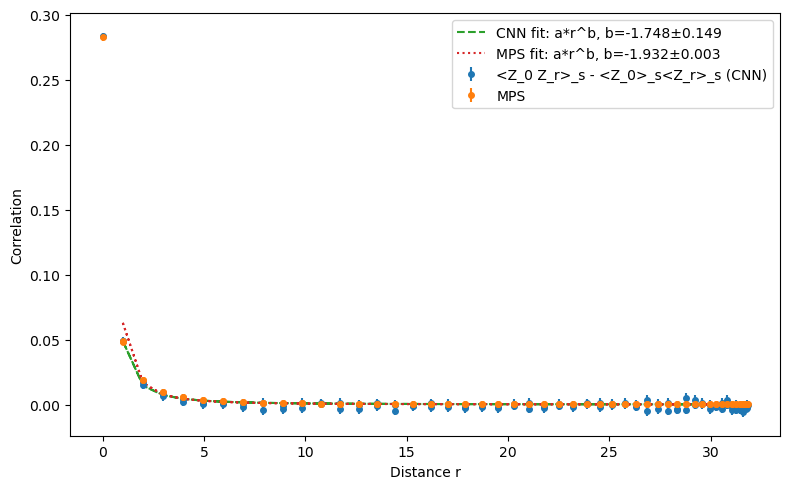

In [72]:
r_list = np.arange(L)
r_chord = L / np.pi * np.sin(np.pi * r_list / L)
Zcorr_data = []
Zcorr_data_std = []
for i in r_list:
    zcorr_i = np.mean(Y[:, 0] * Y[:, i])
    zcorr_i_std = np.std(Y[:, 0] * Y[:, i]) / np.sqrt(Y.shape[0])
    Zcorr_data.append(zcorr_i)
    Zcorr_data_std.append(zcorr_i_std)
Z0Zr_pred = []
Z0Zr_pred_std = []
for r in r_list:
    zpred_r = np.mean(Y_pred[:, 0] * Y_pred[:, r])
    zpred_r_std = np.std(Y_pred[:, 0] * Y_pred[:, r]) / np.sqrt(Y_pred.shape[0])
    Z0Zr_pred.append(zpred_r)
    Z0Zr_pred_std.append(zpred_r_std)
Zcorr_data = np.asarray(Zcorr_data)
Zcorr_data_std = np.asarray(Zcorr_data_std)
Z0Zr_pred = np.asarray(Z0Zr_pred)
Z0Zr_pred_std = np.asarray(Z0Zr_pred_std)
def mps_data(q=1):
    Zcorr = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zcorr_N10000_0_r.npy")
    Z = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")
    _connected_corr = Zcorr - Z[:, :1] * Z
    y = np.mean(np.power(np.abs(_connected_corr), q), axis=0)
    y_std = np.std(np.power(np.abs(_connected_corr), q), axis=0) / np.sqrt(Z.shape[0])
    return y, y_std
y_mps, y_mps_std = mps_data(q=1)
y_cnn = Zcorr_data - Z0Zr_pred
y_cnn_std = np.sqrt(Zcorr_data_std**2 + Z0Zr_pred_std**2)
from scipy.optimize import curve_fit
def fit_func(r, a, b):
    return a * np.power(r, b)
def weighted_power_fit(r, y, sigma, fit_start=1, fit_end=None):
    if fit_end is None:
        fit_end = len(r)
    r_fit = r[fit_start:fit_end]
    y_fit = y[fit_start:fit_end]
    s_fit = sigma[fit_start:fit_end]
    # Keep only physically/numercially valid points for power-law fit.
    mask = (
        np.isfinite(r_fit)
        & np.isfinite(y_fit)
        & np.isfinite(s_fit)
        & (r_fit > 0)
        & (y_fit > 0)
        & (s_fit > 0)
    )
    if np.sum(mask) < 3:
        raise RuntimeError("Not enough valid points for weighted power-law fit.")
    p0 = (float(np.max(y_fit[mask])), -0.25)
    popt, pcov = curve_fit(
        fit_func,
        r_fit[mask],
        y_fit[mask],
        sigma=s_fit[mask],
        absolute_sigma=True,
        p0=p0,
        bounds=([0.0, -np.inf], [np.inf, 0.0]),
        maxfev=20000,
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr
fit_start, fit_end = 1, L
popt_cnn, perr_cnn = weighted_power_fit(r_chord, y_cnn, y_cnn_std, fit_start, fit_end)
popt_mps, perr_mps = weighted_power_fit(r_chord, y_mps, y_mps_std, fit_start, fit_end)
a_cnn, b_cnn = popt_cnn
a_mps, b_mps = popt_mps
b_err_cnn = perr_cnn[1]
b_err_mps = perr_mps[1]
print(f"CNN fit exponent: b = {b_cnn:.6f} ± {b_err_cnn:.6f}")
print(f"MPS fit exponent: b = {b_mps:.6f} ± {b_err_mps:.6f}")
plt.figure(figsize=(8, 5))
plt.errorbar(r_chord, y_cnn, yerr=y_cnn_std, fmt="o", markersize=4, label="<Z_0 Z_r>_s - <Z_0>_s<Z_r>_s (CNN)")
plt.errorbar(r_chord, y_mps, yerr=y_mps_std, fmt="o", markersize=4, label="MPS")
fitted_line_cnn = fit_func(r_chord, *popt_cnn)
fitted_line_mps = fit_func(r_chord, *popt_mps)
plt.plot(r_chord, fitted_line_cnn, linestyle="--", label=f"CNN fit: a*r^b, b={b_cnn:.3f}±{b_err_cnn:.3f}")
plt.plot(r_chord, fitted_line_mps, linestyle=":", label=f"MPS fit: a*r^b, b={b_mps:.3f}±{b_err_mps:.3f}")
plt.xlabel("Distance r")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_3733645/2000546072.py:67: RuntimeWarning: divide by zero encountered in power
  return a * r_c**b + c


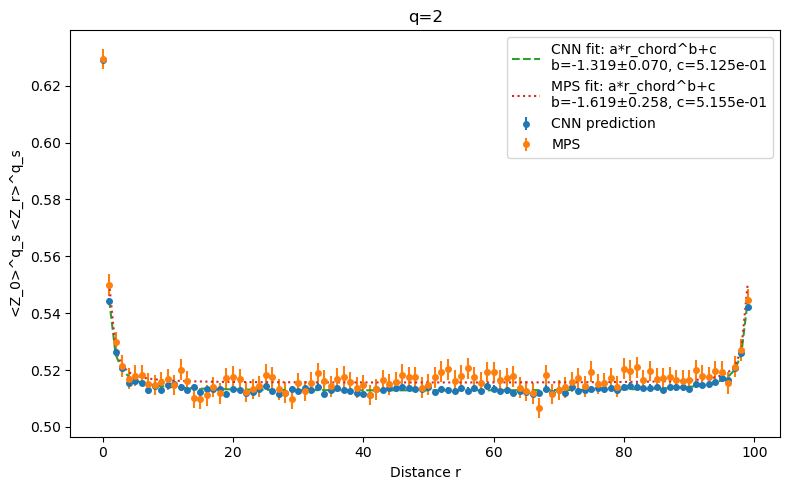

In [83]:
r_list = np.arange(L)
r_chord = L / np.pi * np.sin(np.pi * r_list / L)
def nn_data(q=1):
    Y_pred = np.load("temp/dilatedcnn_sharedpbc_L100_beta0.5_N100000_y_pred.npy")
    y = []
    y_std = []
    for r in r_list:
        vals = Y_pred[:, 0]**q * Y_pred[:, r]**q
        y.append(np.mean(vals))
        y_std.append(np.std(vals) / np.sqrt(Y_pred.shape[0]))
    return np.array(y), np.array(y_std)
def mps_data(q=1):
    Z = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")
    vals = Z[:, :1]**q * Z**q
    y = np.mean(vals, axis=0)
    y_std = np.std(np.abs(vals), axis=0) / np.sqrt(Z.shape[0])
    return y, y_std
q = 2
y_nn, y_nn_std = nn_data(q)
y_mps, y_mps_std = mps_data(q)
plt.figure(figsize=(8, 5))
if q % 2 == 1:
    plt.errorbar(r_chord, y_nn, yerr=y_nn_std, fmt="o", markersize=4, label="CNN prediction")
    plt.errorbar(r_chord, y_mps, yerr=y_mps_std, fmt="o", markersize=4, label="MPS")
    fit_slice = slice(5, -5)
    x_fit = np.log(r_chord[fit_slice])
    # Weighted linear fit in log-log space using error bars.
    y_nn_fit = y_nn[fit_slice]
    s_nn_fit = np.maximum(y_nn_std[fit_slice], 1e-12)
    mask_nn = y_nn_fit > 0
    coef_nn, cov_nn = np.polyfit(
        x_fit[mask_nn],
        np.log(y_nn_fit[mask_nn]),
        deg=1,
        w=1.0 / np.maximum(s_nn_fit[mask_nn] / y_nn_fit[mask_nn], 1e-12),
        cov=True,
    )
    b_nn = coef_nn[0]
    b_nn_err = np.sqrt(cov_nn[0, 0])
    fitted_line_nn = np.exp(coef_nn[1]) * r_chord**b_nn
    plt.plot(r_chord, fitted_line_nn, linestyle="--", label=f"CNN fit: ~r^{b_nn:.3f}±{b_nn_err:.3f}")
    y_mps_fit = y_mps[fit_slice]
    s_mps_fit = np.maximum(y_mps_std[fit_slice], 1e-12)
    mask_mps = y_mps_fit > 0
    coef_mps, cov_mps = np.polyfit(
        x_fit[mask_mps],
        np.log(y_mps_fit[mask_mps]),
        deg=1,
        w=1.0 / np.maximum(s_mps_fit[mask_mps] / y_mps_fit[mask_mps], 1e-12),
        cov=True,
    )
    b_mps = coef_mps[0]
    b_mps_err = np.sqrt(cov_mps[0, 0])
    fitted_line_mps = np.exp(coef_mps[1]) * r_chord**b_mps
    plt.plot(r_chord, fitted_line_mps, linestyle=":", label=f"MPS fit: ~r^{b_mps:.3f}±{b_mps_err:.3f}")
    plt.xlabel("Distance r")
    plt.ylabel("<Z_0>^q_s <Z_r>^q_s")
    plt.title(f"q={q}")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
else:
    plt.errorbar(r_list, y_nn, yerr=y_nn_std, fmt="o", markersize=4, label="CNN prediction")
    plt.errorbar(r_list, y_mps, yerr=y_mps_std, fmt="o", markersize=4, label="MPS")
    def fit_func(r, a, b, c):
        r_c = L / np.pi * np.sin(np.pi * r / L)
        return a * r_c**b + c
    from scipy.optimize import curve_fit
    fit_start, fit_end = 1, L - 1
    sigma_nn = np.maximum(y_nn_std[fit_start:fit_end], 1e-12)
    popt_nn, pcov_nn = curve_fit(
        fit_func,
        r_list[fit_start:fit_end],
        y_nn[fit_start:fit_end],
        sigma=sigma_nn,
        absolute_sigma=True,
        p0=(1, -0.25, 0),
        bounds=([0, -np.inf, 0], [np.inf, 0, np.inf]),
        maxfev=20000,
    )
    b_nn_err = np.sqrt(np.diag(pcov_nn))[1]
    fitted_line_nn = fit_func(r_list, *popt_nn)
    plt.plot(r_list, fitted_line_nn, linestyle="--", label=f"CNN fit: a*r_chord^b+c\nb={popt_nn[1]:.3f}±{b_nn_err:.3f}, c={popt_nn[2]:.3e}")
    sigma_mps = np.maximum(y_mps_std[fit_start:fit_end], 1e-12)
    popt_mps, pcov_mps = curve_fit(
        fit_func,
        r_list[fit_start:fit_end],
        y_mps[fit_start:fit_end],
        sigma=sigma_mps,
        absolute_sigma=True,
        p0=(1, -0.25, 0),
        bounds=([0, -np.inf, 0], [np.inf, 0, np.inf]),
        maxfev=20000,
    )
    b_mps_err = np.sqrt(np.diag(pcov_mps))[1]
    fitted_line_mps = fit_func(r_list, *popt_mps)
    plt.plot(r_list, fitted_line_mps, linestyle=":", label=f"MPS fit: a*r_chord^b+c\nb={popt_mps[1]:.3f}±{b_mps_err:.3f}, c={popt_mps[2]:.3e}")
    plt.xlabel("Distance r")
    plt.ylabel("<Z_0>^q_s <Z_r>^q_s")
    plt.title(f"q={q}")
    plt.legend()
plt.tight_layout()
plt.show()
